In [1]:
from collections import Counter, defaultdict
from functools import partial
from multiprocessing import Pool
from pathlib import Path
from pickle import dump, load
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from matplotlib import ticker
from matplotlib.patches import Patch
from scipy.stats import pearsonr, spearmanrho
from sklearn.linear_model import (
    LogisticRegressionCV,
)
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    cross_val_predict,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


In [2]:
# All relevant paths
project_dir = Path("/orcd/data/manoli/001/rcalef/projects/vep_comparisons/")
figs_dir = project_dir / "figures"

data_dir = Path("/orcd/data/manoli/001/rcalef/data/vep_comparisons/variants")

variants_path = data_dir / "collated_variants.annotated.tsv.gz"

scores_dir = project_dir / "scoring"

flat_score_paths = {
    "esmc": scores_dir / "collated_variants.esmc_600m.tsv.gz",
    "saprot": scores_dir / "collated_variants.saprot_650m.tsv.gz",
    "nt_100": scores_dir / "ntv3_100m_pre_8192_centered" / "all_shards.tsv.gz",
    "nt_650": scores_dir / "ntv3_650m_pre_8192_centered" / "all_shards.tsv.gz",
    "orthrus": scores_dir / "orthrus_mlm_6_track" / "all_shards.tsv.gz",
    "rinalmo": scores_dir / "rinalmo_giga.tsv.gz",
}

# Evo2 scores present as sharded parquet files in different directories
# for different variant datasets.
evo_dir = Path("/orcd/data/manoli/001/iychan25/evo2-clinvar/results/scores_export/")
evo_score_globs = {
    "finucane_v50": "scores_chunk*",
    "multisusie": "scores_chunk*",
    "eqtl": "scores_chunk*",
    "clinvar": "scores_relabeled.parquet",
}

# # RiNaLMo scores present as separate parquet files per dataset.
# rinalmo_dir = Path("/orcd/data/manoli/001/laurieee/new-evaluation/results/")
# rinalmo_score_globs = {
#     "gwas": "scores_chunk*",
#     "eqtl": "scores_chunk*",
#     "clinvar": "scores_chunk*",
# }


def save_fig(name: str):
    plt.savefig(figs_dir / name, bbox_inches="tight")


In [3]:
# Helpful mappings to names, modalities, labels, etc
dataset_labels = {
    "gwas": ["high_pip"],
    "gwas_stringent": ["high_pip"],
    "eqtl": ["high_pip"],
    "clinvar": ["Pathogenic", "Likely_pathogenic"],
}

dataset_names: dict[str, str] = {
    "gwas": "GWAS",
    "gwas_stringent": "GWAS (Stringent)",
    "eqtl": "eQTL",
    "clinvar": "ClinVar",
}

annot_names = {
    "phylop": "phyloP",
    "gnocchi_z": "Gnocchi",
    "gnomadg_af_log": "log(MAF)",
}

score_to_model = {
    "evo_score": "Evo2",
    "nt_100_score": "NTv3 (100M)",
    "nt_650_score": "NTv3",
    "rinalmo_score": "RiNALMo",
    "orthrus_score": "Orthrus",
    "esmc_score": "ESM-C",
    "saprot_score": "SaProt",
    "alphagenome_atlas_raw_score": "AlphaGenome AVI",
}

models_by_modality = {
    "DNA": ["Evo2", "NTv3"],
    "RNA": ["RiNALMo", "Orthrus"],
    "Protein": ["ESM-C", "SaProt"],
}
model_to_modality = {
    name: modality for modality, models in models_by_modality.items() for name in models
}

gpn_score_cols = {
    "gpn_star_v_score": "GPN-Star (V)",
    "gpn_star_m_score": "GPN-Star (M)",
    "gpn_star_p_score": "GPN-Star (P)",
}

all_models = score_to_model.copy()
all_models.update(gpn_score_cols)
model_to_score = {v: k for k, v in all_models.items()}

pretty_names = {}
pretty_names.update(annot_names)
pretty_names.update(all_models)

annot_colors = {
    "phyloP": "#52bcba",
    "Gnocchi": "#c463a5",
}

modality_colors = {
    "DNA": "#5e4099",
    "RNA": "#b75265",
    "Protein": "#1c75bc",
}

In [4]:
_ = pl.Config.set_tbl_rows(20)

# Load all data

Load and merge the following:
- Variants w/ annotations (PhyloP, Gnocchi, Roulette)
    - Create merged "GWAS" group that combines UKBB/Finucane and MultiSuSiE
- Model scores for variant positions
    - Protein models (protein-coding missense variants only)
        - ESM-C 300M
        - SaProt
    - RNA models
        - RiNALMo
        - Orthrus (6-track with MLM objective)
    - DNA models
        - Evo2 7B: p(ref), p(alt), log-likelihood ratio. Both averaged over forward and reverse direction
        - Nucleotide Transformer V3 (100M and 650M)

In [5]:
# Load variants w/ annotations
df = (
    pl.read_csv(
        variants_path,
        separator="\t",
        null_values="-",
        schema_overrides={
            "multisusie_pip": pl.Float64,
            "eqtl_pip": pl.Float64,
        },
    )
    # Remove 1bp deletions and splice site variants in introns
    .filter(
        pl.col("alt") != ".",
        pl.col("cdna_position").is_not_null(),
    )
    .with_columns(
        gnomadg_af_log=(
            pl.when(pl.col("gnomadg_af") == 0)
            .then(None)
            .otherwise(pl.col("gnomadg_af").log10())
        ),
        log_roulette_mr=pl.col("roulette_mr").log10(),
        # Negate GPN-Star score columns to get log(ref) - log(alt),
        # consistent with other models
        **{col: -pl.col(col) for col in gpn_score_cols},
    )
)

print(df.shape)
df.head()

(333420, 44)


variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,alphagenome_atlas_raw_score,gpn_star_v_score,gpn_star_m_score,gpn_star_p_score,gnomadg_af_log,log_roulette_mr
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",0.00385,0.197,-2.525,-1.746,-0.936291,0.104828
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.2079,0.642,-2.522,-1.702,-0.96138,0.326336
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",0.00358,-0.972,1.645,0.667,-1.159831,-1.026872
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-0.01593,0.229,-0.192,-0.294,-1.101549,-0.978811
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",0.08681,0.502,1.344,0.963,-1.02278,-0.038105


In [6]:
gpn_cols = [
    "gpn_star_v_score",
    "gpn_star_m_score",
    "gpn_star_p_score",
]

df.select(gpn_cols).describe()

statistic,gpn_star_v_score,gpn_star_m_score,gpn_star_p_score
str,f64,f64,f64
"""count""",333420.0,333419.0,333419.0
"""null_count""",0.0,1.0,1.0
"""mean""",1.081489,0.916052,0.847624
"""std""",3.236968,3.598905,3.379524
"""min""",-14.699,-14.918,-13.856
"""25%""",-0.764,-0.679,-0.703
"""50%""",0.475,1.074,0.92
"""75%""",2.23,2.564,2.711
"""max""",14.12,12.906,12.413


In [7]:
# Keep UKBB evidence only for the selected traits. The upstream curation
# notebook applies this restriction before maximizing PIP across traits.
ukbb_dir = data_dir / "ukbb_finucane"
ukbb_want_traits = pl.read_csv(
    ukbb_dir / "UKBB_94traits_release1.traits.filtered",
    separator="\t",
)
ukbb_variants = pl.read_csv(
    ukbb_dir / "final_UKBB_94traits_release1.hg38.selected_transcript.txt.gz",
    separator="\t",
    columns=["variant", "trait", "pip"],
)


def restrict_ukbb_traits(
    data: pl.DataFrame,
    ukbb_variants: pl.DataFrame,
    traits: list[str],
) -> pl.DataFrame:
    eligible = (
        ukbb_variants.filter(pl.col("trait").is_in(traits))
        .group_by("variant")
        .agg(ukbb_pip=pl.col("pip").max())
        .with_columns(
            ukbb_label=(
                pl.when(pl.col("ukbb_pip") >= 0.5)
                .then(pl.lit("high_pip"))
                .when(pl.col("ukbb_pip") <= 0.1)
                .then(pl.lit("low_pip"))
                .otherwise(None)
            ),
        )
        .filter(pl.col("ukbb_label").is_not_null())
    )
    return (
        data.drop("ukbb_pip", "ukbb_label")
        .join(eligible, on="variant", how="left", maintain_order="left")
        # Keep variants used by other datasets even without eligible UKBB evidence.
        .filter(
            pl.any_horizontal(
                pl.col(
                    "ukbb_label", "multisusie_label", "eqtl_label", "clinvar_label"
                ).is_not_null()
            )
        )
        .with_columns(gwas_pip=pl.max_horizontal("ukbb_pip", "multisusie_pip"))
        .with_columns(
            gwas_label=(
                pl.when(pl.col("gwas_pip") >= 0.5)
                .then(pl.lit("high_pip"))
                .otherwise(
                    pl.when(pl.col("gwas_pip") <= 0.1)
                    .then(pl.lit("low_pip"))
                    .otherwise(None)
                )
            ),
            gwas_stringent_label=(
                pl.when(pl.col("gwas_pip") >= 0.9)
                .then(pl.lit("high_pip"))
                .otherwise(
                    pl.when(pl.col("gwas_pip") <= 0.01)
                    .then(pl.lit("low_pip"))
                    .otherwise(None)
                )
            ),
        )
    )


len_before = len(df)
df = restrict_ukbb_traits(df, ukbb_variants, ukbb_want_traits["trait"].to_list())
print(f"{len_before} -> {len(df)}")


333420 -> 329585


In [8]:
def load_score_file(
    path: Path,
    name: str,
    negate_score: bool = True,
) -> pl.DataFrame:
    scores = pl.read_csv(
        path,
        separator="\t",
        columns=("variant", "gene", "feature", "score"),
    )

    if negate_score:
        # Some original scores are log(alt) - log(ref), so negate
        # so we have "pathogenicity" scores, i.e. a score that's
        # high when the alt allele is very low probability
        scores = scores.with_columns(score=-pl.col("score"))

    print(f"{name}: {len(scores)}")
    return scores.rename({"score": f"{name}_score"})


flat_scores = {
    name: load_score_file(path, name, negate_score=True)
    for name, path in flat_score_paths.items()
}

esmc: 48491
saprot: 38290
nt_100: 340299
nt_650: 340299
orthrus: 333420
rinalmo: 333420


In [9]:
def load_one_evo(path: Path, glob: str) -> pl.DataFrame:
    evo_scores = (
        pl.concat([pl.read_parquet(path) for path in sorted(path.glob(glob))])
        .with_columns(chrom=pl.col("chrom").cast(pl.String))
        .with_columns(
            chrom=pl.when(pl.col("chrom").str.contains("chr"))
            .then(pl.col("chrom"))
            .otherwise(pl.format("chr{}", "chrom")),
            evo_ref_prob=pl.mean_horizontal(
                pl.col("score_ref_fwd").exp(), pl.col("score_ref_rev").exp()
            ),
            evo_alt_prob=pl.mean_horizontal(
                pl.col("score_alt_fwd").exp(), pl.col("score_alt_rev").exp()
            ),
        )
        .with_columns(
            variant=pl.format("{}:{}:{}:{}", "chrom", "pos", "ref", "alt"),
            evo_score=pl.col("evo_ref_prob").log() - pl.col("evo_alt_prob").log(),
        )
        .select(
            "variant",
            "evo_ref_prob",
            "evo_alt_prob",
            "evo_score",
        )
    )
    return evo_scores


all_evo_scores = pl.concat(
    [load_one_evo(evo_dir / name, glob) for (name, glob) in evo_score_globs.items()],
    how="diagonal",
).unique("variant")
all_evo_scores.shape

(469215, 4)

In [10]:
def merge_and_report(
    df: pl.DataFrame,
    oth: pl.DataFrame,
    on: list[str],
    name: str,
) -> pl.DataFrame:
    merged = df.join(oth, on=on, how="left")
    present = merged.get_column(f"{name}_score").is_not_null().sum()
    print(f"{name}: {len(oth)} -> {present} merged")
    return merged


flat_scores.update(
    {
        "evo": all_evo_scores,
        # "rinalmo": all_rinalmo_scores,
    }
)

for name, vals in flat_scores.items():
    cols = ["variant"] if name == "evo" else ["variant", "gene", "feature"]
    df = merge_and_report(df, vals, on=cols, name=name)

print(df.shape)
df.head()

esmc: 48491 -> 48149 merged
saprot: 38290 -> 38017 merged
nt_100: 340299 -> 329585 merged
nt_650: 340299 -> 329585 merged
orthrus: 333420 -> 329585 merged
rinalmo: 333420 -> 329585 merged
evo: 469215 -> 315327 merged
(329585, 56)


variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,alphagenome_atlas_raw_score,gpn_star_v_score,gpn_star_m_score,gpn_star_p_score,gnomadg_af_log,log_roulette_mr,ukbb_pip,ukbb_label,gwas_pip,gwas_label,gwas_stringent_label,esmc_score,saprot_score,nt_100_score,nt_650_score,orthrus_score,rinalmo_score,evo_ref_prob,evo_alt_prob,evo_score
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,str,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",0.00385,0.197,-2.525,-1.746,-0.936291,0.104828,0.004209,"""low_pip""",0.004209,"""low_pip""","""low_pip""",null,null,-1.512764,-1.637647,-0.138533,-1.1875,0.314054,0.314115,-0.000196
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.2079,0.642,-2.522,-1.702,-0.96138,0.326336,0.004478,"""low_pip""",0.004478,"""low_pip""","""low_pip""",null,null,-0.702198,-0.67272,0.84236,-0.375,0.336628,0.33667,-0.000124
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",0.00358,-0.972,1.645,0.667,-1.159831,-1.026872,0.003612,"""low_pip""",0.003612,"""low_pip""","""low_pip""",null,null,1.423264,1.435684,0.052534,3.125,0.329573,0.329497,0.000231
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-0.01593,0.229,-0.192,-0.294,-1.101549,-0.978811,0.002221,"""low_pip""",0.002221,"""low_pip""","""low_pip""",null,null,1.492862,1.665321,0.893877,1.5625,0.318683,0.318626,0.000177
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",0.08681,0.502,1.344,0.963,-1.02278,-0.038105,0.002458,"""low_pip""",0.002458,"""low_pip""","""low_pip""",null,null,0.018063,-0.407629,-0.602901,-0.625,0.306684,0.306683,0.000003


# Table 1: Variant counts by dataset

In [ ]:
(
    df.with_columns(
        **{
            ds_name: pl.when(pl.col(f"{ds_name}_label").is_null())
            .then(None)
            .otherwise(
                pl.when(pl.col(f"{ds_name}_label").is_in(pos_labels))
                .then(pl.lit("pos"))
                .otherwise(pl.lit("neg"))
            )
            for ds_name, pos_labels in dataset_labels.items()
        }
    )
    .select(*dataset_labels.keys())
    .unpivot(variable_name="dataset", value_name="label")
    .pivot(on="dataset", values="dataset", aggregate_function="len")
    .filter(pl.col("label").is_not_null())
)

In [ ]:
stats = (
    df.unique("variant")
    .with_columns(
        **{
            ds_name: pl.when(pl.col(f"{ds_name}_label").is_null())
            .then(None)
            .otherwise(
                pl.when(pl.col(f"{ds_name}_label").is_in(pos_labels))
                .then(pl.lit("pos"))
                .otherwise(pl.lit("neg"))
            )
            for ds_name, pos_labels in dataset_labels.items()
        }
    )
    .select(*dataset_labels.keys(), "gnomadg_af")
    .unpivot(index="gnomadg_af", variable_name="dataset", value_name="label")
    .filter(pl.col("label").is_not_null())
    .group_by(pl.col("dataset", "label"))
    .agg(
        N=pl.col("gnomadg_af").len(),
        maf_mid=pl.col("gnomadg_af").median(),
        maf_high=pl.col("gnomadg_af").quantile(0.75),
        maf_low=pl.col("gnomadg_af").quantile(0.25),
    )
    .sort(by=["dataset", "label"])
    # .pivot(
    #     on=pl.col("dataset", "label"),
    #     index=pl.col("dataset", "label"),
    #     aggregate_function="len",
    # )
    # .pivot(on="label", values="label", aggregate_function="len")
    # .filter(pl.col("label").is_not_null())
    # .transpose(include_header=True)
)
stats

In [ ]:
df.unique("variant").height

In [ ]:
stats.get_column("N").sum()

In [ ]:
1655 + 10817

In [ ]:
(
    df.unique("variant")
    .with_columns(
        **{
            ds_name: pl.when(pl.col(f"{ds_name}_label").is_null())
            .then(None)
            .otherwise(
                pl.when(pl.col(f"{ds_name}_label").is_in(pos_labels))
                .then(pl.lit("pos"))
                .otherwise(pl.lit("neg"))
            )
            for ds_name, pos_labels in dataset_labels.items()
        }
    )
    .select(*dataset_labels.keys())
    .unpivot(variable_name="dataset", value_name="label")
    .filter(pl.col("label").is_not_null())
    .pivot(index="dataset", on="label", values="label", aggregate_function="len")
    .with_columns(pos_frac=pl.col("pos") / (pl.col("pos") + pl.col("neg")))
)

In [ ]:
# Protein-coding missense only
ms_stats = (
    df.unique("variant")
    .with_columns(
        **{
            ds_name: pl.when(pl.col(f"{ds_name}_label").is_null())
            .then(None)
            .otherwise(
                pl.when(pl.col(f"{ds_name}_label").is_in(pos_labels))
                .then(pl.lit("pos"))
                .otherwise(pl.lit("neg"))
            )
            for ds_name, pos_labels in dataset_labels.items()
        }
    )
    .filter(pl.col("esmc_score").is_not_null())
    .select(*dataset_labels.keys(), "gnomadg_af")
    .unpivot(index="gnomadg_af", variable_name="dataset", value_name="label")
    .filter(pl.col("label").is_not_null())
    .group_by(pl.col("dataset", "label"))
    .agg(
        N=pl.col("gnomadg_af").len(),
        maf_mid=pl.col("gnomadg_af").median(),
        maf_high=pl.col("gnomadg_af").quantile(0.75),
        maf_low=pl.col("gnomadg_af").quantile(0.25),
    )
    .sort(by=["dataset", "label"])
    # .pivot(
    #     on=pl.col("dataset", "label"),
    #     index=pl.col("dataset", "label"),
    #     aggregate_function="len",
    # )
    # .pivot(on="label", values="label", aggregate_function="len")
    # .filter(pl.col("label").is_not_null())
    # .transpose(include_header=True)
)
ms_stats

In [ ]:
ms_stats.get_column("N").sum()

In [ ]:
(df.unique("variant").filter(pl.col("esmc_score").is_not_null()).height)

In [ ]:
(df.unique("variant").filter(pl.col("saprot_score").is_not_null()).height)

In [ ]:
df.unique("variant").filter(pl.col("esmc_score").is_not_null()).get_column(
    "gnomadg_af"
).describe()

# Figure 3: Correlation of annotations with model scores

In [35]:
def get_fixed_zero_lims(
    ymin: float,
    ymax: float,
    target_pos: float = 0.2,
) -> tuple[float, float]:
    current_pos = abs(ymin) / (ymax - ymin)
    print(current_pos)
    if current_pos > target_pos:
        new_ymax = abs(ymin) / target_pos
        new_ymin = ymin
    elif current_pos < target_pos:
        new_ymax = ymax
        new_ymin = -ymax * target_pos
    else:
        new_ymax = ymax
        new_ymin = ymin
    return new_ymin, new_ymax


def model_annotation_correlation_facet(
    ax: plt.Axes,
    df: pl.DataFrame,
    model: str,
    want_annots: list[str] = ["gnocchi_z", "phylop"],
    target_zero_pos: float = 0.2,
    use_z_scores: bool = False,
) -> list[dict]:
    """Plot annotation correlations for a single model on one axis."""
    score_col = model_to_score[model]

    plot_data = df.filter(
        pl.col(score_col).is_not_null(),
        pl.all_horizontal(pl.col(want_annots).is_not_null()),
    )

    corrs = []

    for k, annot in enumerate(want_annots):
        annot_name = annot_names[annot]

        # Use annotation-specific data so transformations don't carry
        # over between iterations.
        annot_data = plot_data

        if use_z_scores:
            annot_data = annot_data.with_columns(
                (pl.col(score_col) - pl.col(score_col).mean())
                / pl.col(score_col).std(),
                (pl.col(annot) - pl.col(annot).mean()) / pl.col(annot).std(),
            )

        x_vals = annot_data.get_column(annot).to_numpy()
        y_vals = annot_data.get_column(score_col).to_numpy()

        r = pearsonr(x_vals, y_vals)
        rho = spearmanrho(x_vals, y_vals)

        col = annot_colors[annot_name]

        sns.kdeplot(
            x=annot,
            y=score_col,
            alpha=0.3,
            color=col,
            data=annot_data.sample(fraction=0.01),
            ax=ax,
        )

        sns.regplot(
            x=annot,
            y=score_col,
            line_kws={"color": col},
            n_boot=10,
            data=annot_data,
            scatter=False,
            truncate=False,
            ax=ax,
        )

        ax.text(
            0.05 if k == 1 else 0.95,
            0.95,
            s=(
                f"r={r.statistic:0.2f}"
                "\n"
                rf"$\rho$={rho.statistic:0.2f}"
            ),
            transform=ax.transAxes,
            ha="left" if k == 1 else "right",
            va="top",
            color=col,
            bbox={"facecolor": "grey", "alpha": 0.05, "pad": 0.3},
        )

        corrs.append(
            {
                "model_name": model,
                "annot": annot_name,
                "pearson": r.statistic,
                "spearman": rho.statistic,
            }
        )

    # Axis limits should only need to be set once per facet.
    if use_z_scores:
        ax.set_xlim(-4, 4)
        ax.set_ylim(-3, 3)
    else:
        ax.set_xlim(-10, 10)

        y_vals = plot_data.get_column(score_col).to_numpy()
        ymin, ymax = np.quantile(y_vals, q=(0.025, 0.975))
        ax.set_ylim(*get_fixed_zero_lims(ymin, ymax, target_zero_pos))

    ax.yaxis.set_major_locator(plt.MaxNLocator(3))

    return corrs


def model_annotation_correlation_plot(
    df: pl.DataFrame,
    want_annots: list[str] = ["gnocchi_z", "phylop"],
    target_zero_pos: float = 0.2,
    use_z_scores: bool = False,
) -> pl.DataFrame:
    """Create the complete model × modality correlation figure."""
    fig, axs = plt.subplots(
        nrows=2,
        ncols=len(models_by_modality),
        sharex=True,
        sharey=False,
        figsize=(10, 6),
        gridspec_kw={"hspace": 0.3},
    )
    sns.despine(fig)

    all_corrs = []

    for j, (modality, models) in enumerate(models_by_modality.items()):
        assert len(models) == 2

        for i, model in enumerate(models):
            ax = axs[i, j]

            corrs = model_annotation_correlation_facet(
                ax=ax,
                df=df,
                model=model,
                want_annots=want_annots,
                target_zero_pos=target_zero_pos,
                use_z_scores=use_z_scores,
            )
            all_corrs.extend(corrs)

            title = model
            if i == 0:
                title = f"{modality} models\n\n{title}"
            ax.set_title(title)

            ax.set_xlabel("Annotation" if i == 1 else "")
            ax.set_ylabel("Model score" if j == 0 else None)

    legend_elements = [
        Patch(facecolor=color, label=annot) for annot, color in annot_colors.items()
    ]

    axs[-1, -1].legend(
        title="Annotation",
        handles=legend_elements,
        bbox_to_anchor=(1.05, 1),
        loc="lower left",
        frameon=False,
    )

    return pl.DataFrame(all_corrs)

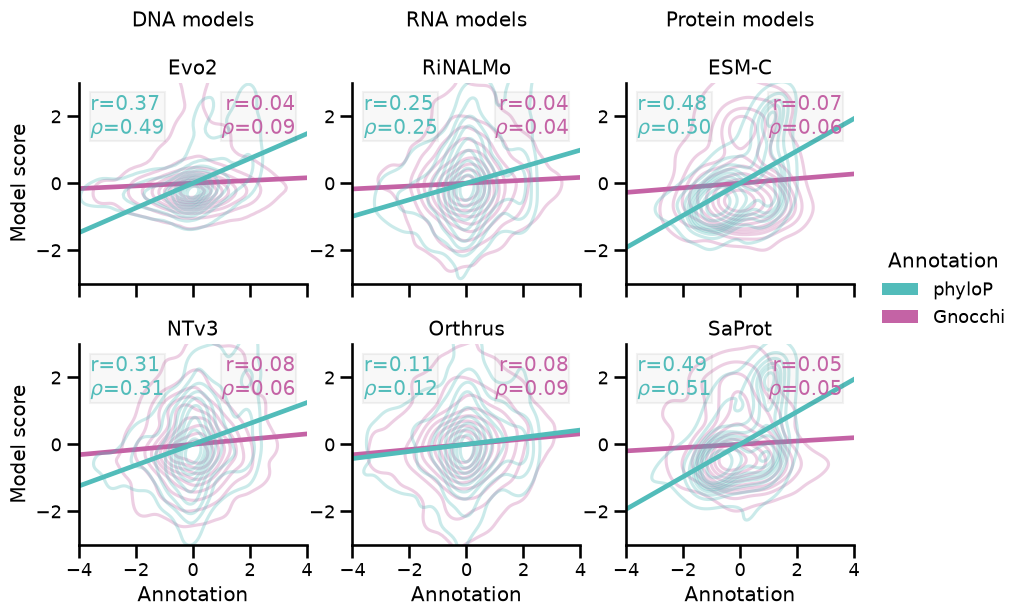

In [61]:
with sns.plotting_context("talk", font_scale=0.8):
    all_corrs = model_annotation_correlation_plot(
        df,
        use_z_scores=True,
    )
    # save_fig("fig3_scores_vs_annots.pdf")


In [ ]:
with sns.plotting_context("talk", font_scale=0.8):
    all_corrs = model_annotation_correlation_plot(
        df,
    )
    save_fig("app_fig_scores_vs_annots.raw_values.pdf")


### GPN-Star only plots

In [36]:
def gpn_star_annotation_correlation_plot(
    df: pl.DataFrame,
    want_annots: list[str] = ["gnocchi_z", "phylop"],
    target_zero_pos: float = 0.2,
    use_z_scores: bool = False,
) -> pl.DataFrame:
    fig, axs = plt.subplots(
        nrows=1,
        ncols=len(gpn_score_cols),
        sharex=True,
        sharey=False,
        figsize=(10, 6),
        gridspec_kw={
            "hspace": 0.3,
        },
    )
    sns.despine(fig)

    all_corrs = []
    for j, (score_col, name) in enumerate(gpn_score_cols.items()):
        plot_data = df.filter(
            pl.col(score_col).is_not_null(),
            pl.all_horizontal(pl.col(want_annots).is_not_null()),
        )

        ax = axs[j]

        for k, annot in enumerate(want_annots):
            annot_name = annot_names[annot]

            if use_z_scores:
                plot_data = plot_data.with_columns(
                    **{
                        score_col: (pl.col(score_col) - pl.col(score_col).mean())
                        / pl.col(score_col).std(),
                        annot: (pl.col(annot) - pl.col(annot).mean())
                        / pl.col(annot).std(),
                    }
                )

            x_vals = plot_data.get_column(annot).to_numpy()
            y_vals = plot_data.get_column(score_col).to_numpy()

            r = pearsonr(x_vals, y_vals)
            rho = spearmanrho(x_vals, y_vals)

            col = annot_colors[annot_name]

            sns.kdeplot(
                x=annot,
                y=score_col,
                alpha=0.3,
                color=col,
                data=plot_data.sample(fraction=0.01),
                # levels=[0.1, 0.25, 0.5, 0.75],
                ax=ax,
            )
            if use_z_scores:
                ax.set_xlim(-4, 4)
                ax.set_ylim(-3, 3)
            else:
                ax.set_xlim(-10, 10)
                ymin, ymax = np.quantile(y_vals, q=(0.025, 0.975))
                ax.set_ylim(*get_fixed_zero_lims(ymin, ymax, target_zero_pos))

            ax.yaxis.set_major_locator(plt.MaxNLocator(3))

            sns.regplot(
                x=annot,
                y=score_col,
                line_kws={
                    "color": col,
                    # "alpha": 0.7,
                },
                n_boot=10,
                data=plot_data,
                scatter=False,
                truncate=False,
                ax=ax,
            )

            ax.text(
                0.05 if k == 1 else 0.95,
                0.95,
                s=(
                    f"r={r.statistic:0.2f}"
                    "\n"
                    rf"$\rho$={rho.statistic:0.2f}"
                ),
                transform=ax.transAxes,
                ha="left" if k == 1 else "right",
                va="top",
                color=col,
                bbox={"facecolor": "grey", "alpha": 0.05, "pad": 0.3},
            )
            title = name

            ax.set_title(title)

            all_corrs.append(
                {
                    "model_name": name,
                    "annot": annot_name,
                    "pearson": r.statistic,
                    "spearman": rho.statistic,
                }
            )

        ax.set_xlabel("Annotation")

        if j == 0:
            ax.set_ylabel("Model score")
        else:
            ax.set_ylabel(None)

    legend_elements = [
        Patch(facecolor=color, label=annot) for annot, color in annot_colors.items()
    ]

    axs[-1].legend(
        title="Annotation",
        handles=legend_elements,
        bbox_to_anchor=(1.05, 1),
        loc="lower left",
        frameon=False,
    )

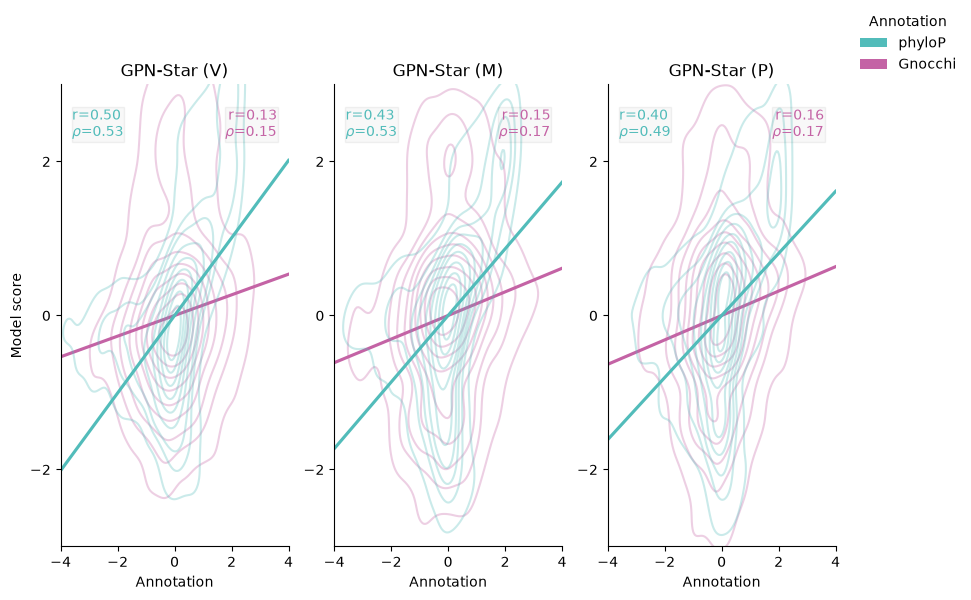

In [38]:
gpn_star_annotation_correlation_plot(df, use_z_scores=True)

### AlphaGenome correlations

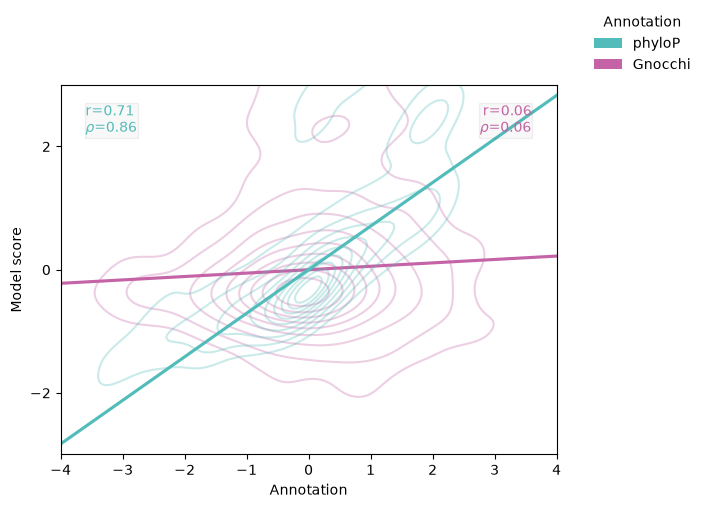

In [32]:
ag_score_col = "alphagenome_atlas_raw_score"
want_annots = ["gnocchi_z", "phylop"]
plot_data = df.filter(
    pl.col(ag_score_col).is_not_null(),
    pl.all_horizontal(pl.col(want_annots).is_not_null()),
)

all_corrs = []
ax = None
for k, annot in enumerate(want_annots):
    annot_name = annot_names[annot]

    plot_data = plot_data.with_columns(
        **{
            ag_score_col: (pl.col(ag_score_col) - pl.col(ag_score_col).mean())
            / pl.col(ag_score_col).std(),
            annot: (pl.col(annot) - pl.col(annot).mean()) / pl.col(annot).std(),
        }
    )

    x_vals = plot_data.get_column(annot).to_numpy()
    y_vals = plot_data.get_column(ag_score_col).to_numpy()

    r = pearsonr(x_vals, y_vals)
    rho = spearmanrho(x_vals, y_vals)

    col = annot_colors[annot_name]

    ax = sns.kdeplot(
        x=annot,
        y=ag_score_col,
        alpha=0.3,
        color=col,
        data=plot_data.sample(fraction=0.01),
        # levels=[0.1, 0.25, 0.5, 0.75],
        ax=ax,
    )
    ax.set_xlim(-4, 4)
    ax.set_ylim(-3, 3)

    ax.yaxis.set_major_locator(plt.MaxNLocator(3))

    sns.regplot(
        x=annot,
        y=ag_score_col,
        line_kws={
            "color": col,
            # "alpha": 0.7,
        },
        n_boot=10,
        data=plot_data,
        scatter=False,
        truncate=False,
        ax=ax,
    )

    ax.text(
        0.05 if k == 1 else 0.95,
        0.95,
        s=(
            f"r={r.statistic:0.2f}"
            "\n"
            rf"$\rho$={rho.statistic:0.2f}"
        ),
        transform=ax.transAxes,
        ha="left" if k == 1 else "right",
        va="top",
        color=col,
        bbox={"facecolor": "grey", "alpha": 0.05, "pad": 0.3},
    )

    all_corrs.append(
        {
            "model_name": name,
            "annot": annot_name,
            "pearson": r.statistic,
            "spearman": rho.statistic,
        }
    )


legend_elements = [
    Patch(facecolor=color, label=annot) for annot, color in annot_colors.items()
]
ax.set_xlabel("Annotation")
ax.set_ylabel("Model score")

ax.legend(
    title="Annotation",
    handles=legend_elements,
    bbox_to_anchor=(1.05, 1),
    loc="lower left",
    frameon=False,
)

# Appendix Figure 1: phyloP vs Gnocchi

In [ ]:
with sns.plotting_context("talk", font_scale=0.8):
    want_annots = ["phylop", "gnocchi_z"]
    plot_data = df.filter(pl.all_horizontal(pl.col(want_annots).is_not_null())).select(
        want_annots
    )

    ax = sns.histplot(x="phylop", y="gnocchi_z", data=plot_data)

    sns.regplot(
        x="phylop",
        y="gnocchi_z",
        scatter=False,
        ax=ax,
        data=plot_data,
    )

    xvals = plot_data.get_column("phylop").to_numpy()
    yvals = plot_data.get_column("gnocchi_z").to_numpy()

    r = pearsonr(xvals, yvals)
    rho = spearmanrho(xvals, yvals)
    ax.text(
        0.05,
        0.95,
        s=(
            f"r={r.statistic:0.2f}"
            "\n"
            rf"$\rho$={rho.statistic:0.2f}"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        size="small",
    )
    ax.set_xlabel("phyloP")
    ax.set_ylabel("Gnocchi")
    sns.despine(ax=ax)

    save_fig("app_fig1_phylop_vs_gnocchi.pdf")

# Table 2: Model classification of binned annotations

In [11]:
flip = ["gnomadg_af_log"]
results = []
for model, model_name in all_models.items():
    for annot, annot_name in annot_names.items():
        want_data = df.filter(
            pl.col(model).is_not_null(),
            pl.col(annot).is_not_null(),
        )
        low_thresh, high_thresh = want_data.get_column(annot).quantile([0.25, 0.75])

        high_label = 0 if annot in flip else 1
        low_label = 1 if annot in flip else 0

        labeled_data = want_data.with_columns(
            label=(
                pl.when(pl.col(annot) <= low_thresh)
                .then(low_label)
                .otherwise(
                    pl.when(pl.col(annot) >= high_thresh)
                    .then(high_label)
                    .otherwise(None)
                )
            )
        ).filter(pl.col("label").is_not_null())
        y_true = labeled_data.get_column("label")
        y_score = labeled_data.get_column(model)
        results.append(
            {
                "model": model_name,
                "annotation": annot_name,
                "auroc": roc_auc_score(y_true=y_true, y_score=y_score),
                "auprc": average_precision_score(y_true=y_true, y_score=y_score),
                "num_pos": y_true.sum(),
                "num_neg": len(y_true) - y_true.sum(),
            }
        )
results = pl.DataFrame(results)
results

model,annotation,auroc,auprc,num_pos,num_neg
str,str,f64,f64,i64,i64
"""Evo2""","""phyloP""",0.838214,0.866503,78848,78830
"""Evo2""","""Gnocchi""",0.573088,0.555961,53941,53942
"""Evo2""","""log(MAF)""",0.709823,0.728732,66010,66004
"""NTv3 (100M)""","""phyloP""",0.658854,0.653588,82407,82391
"""NTv3 (100M)""","""Gnocchi""",0.539454,0.530529,56393,56394
"""NTv3 (100M)""","""log(MAF)""",0.563736,0.553314,69331,69328
"""NTv3""","""phyloP""",0.718373,0.733728,82407,82391
"""NTv3""","""Gnocchi""",0.549371,0.551978,56393,56394
"""NTv3""","""log(MAF)""",0.5876,0.588913,69331,69328


In [12]:
(
    results.filter(
        pl.col("model") != "NTv3 (100M)",
        pl.col("annotation") != "log(MAF)",
    )
    .with_columns(modality=pl.col("model").replace(model_to_modality))
    .select("modality", "model", "annotation", "auroc")
)

modality,model,annotation,auroc
str,str,str,f64
"""DNA""","""Evo2""","""phyloP""",0.838214
"""DNA""","""Evo2""","""Gnocchi""",0.573088
"""DNA""","""NTv3""","""phyloP""",0.718373
"""DNA""","""NTv3""","""Gnocchi""",0.549371
"""RNA""","""RiNALMo""","""phyloP""",0.677725
"""RNA""","""RiNALMo""","""Gnocchi""",0.533014
"""RNA""","""Orthrus""","""phyloP""",0.577727
"""RNA""","""Orthrus""","""Gnocchi""",0.566287
"""Protein""","""ESM-C""","""phyloP""",0.862592


In [13]:
(
    results.filter(pl.col("model") != "NTv3 (100M)")
    .group_by("annotation")
    .agg(
        auroc=pl.col("auroc").median(),
        auprc=pl.col("auprc").median(),
    )
)

annotation,auroc,auprc
str,f64,f64
"""log(MAF)""",0.71405,0.736811
"""Gnocchi""",0.557829,0.556136
"""phyloP""",0.860347,0.882533


In [14]:
# Shared sites only
results = []

shared_data = df.filter(pl.all_horizontal(pl.col(*score_to_model.keys())).is_not_null())

for model, model_name in score_to_model.items():
    for annot, annot_name in annot_names.items():
        want_data = shared_data.filter(
            pl.col(model).is_not_null(),
            pl.col(annot).is_not_null(),
        )
        low_thresh, high_thresh = want_data.get_column(annot).quantile([0.25, 0.75])

        high_label = 0 if annot in flip else 1
        low_label = 1 if annot in flip else 0

        labeled_data = want_data.with_columns(
            label=(
                pl.when(pl.col(annot) <= low_thresh)
                .then(low_label)
                .otherwise(
                    pl.when(pl.col(annot) >= high_thresh)
                    .then(high_label)
                    .otherwise(None)
                )
            )
        ).filter(pl.col("label").is_not_null())
        y_true = labeled_data.get_column("label")
        y_score = labeled_data.get_column(model)
        results.append(
            {
                "model": model_name,
                "annotation": annot_name,
                "auroc": roc_auc_score(y_true=y_true, y_score=y_score),
                "auprc": average_precision_score(y_true=y_true, y_score=y_score),
                "num_pos": y_true.sum(),
                "num_neg": len(y_true) - y_true.sum(),
            }
        )
results = pl.DataFrame(results)
results

model,annotation,auroc,auprc,num_pos,num_neg
str,str,f64,f64,i64,i64
"""Evo2""","""phyloP""",0.953318,0.944652,11423,11421
"""Evo2""","""Gnocchi""",0.57502,0.537553,8041,8042
"""Evo2""","""log(MAF)""",0.806504,0.796986,9472,9472
"""NTv3 (100M)""","""phyloP""",0.564707,0.585799,11546,11540
"""NTv3 (100M)""","""Gnocchi""",0.519105,0.529476,8130,8130
"""NTv3 (100M)""","""log(MAF)""",0.483707,0.504502,9585,9584
"""NTv3""","""phyloP""",0.756248,0.801055,11546,11540
"""NTv3""","""Gnocchi""",0.567745,0.582673,8130,8130
"""NTv3""","""log(MAF)""",0.600543,0.640138,9585,9584


In [15]:
(
    results.filter(pl.col("model") != "NTv3 (100M)")
    .group_by("annotation")
    .agg(
        auroc=pl.col("auroc").median(),
        auprc=pl.col("auprc").median(),
    )
)

annotation,auroc,auprc
str,f64,f64
"""phyloP""",0.864142,0.879944
"""Gnocchi""",0.537495,0.541094
"""log(MAF)""",0.729075,0.757236


# Figure 2: MAF and phyloP by dataset

In [ ]:
def melt_scores(df: pl.DataFrame, name: str) -> pl.DataFrame:
    return (
        df.unpivot(
            on=["phylop", "gnomadg_af_log", "gnocchi_z"],
            index="variant",
        )
        .with_columns(dataset=pl.lit(name))
        .filter(pl.col("value").is_not_null())
    )


plot_data = pl.concat(
    (
        melt_scores(
            df.filter(
                pl.col("gwas_label").is_not_null(), pl.col("gwas_label") == "high_pip"
            ),
            "GWAS",
        ),
        melt_scores(
            df.filter(
                pl.col("eqtl_label").is_not_null(), pl.col("eqtl_label") == "high_pip"
            ),
            "eQTL",
        ),
        melt_scores(
            df.filter(
                pl.col("clinvar_label").is_not_null(),
                pl.col("clinvar_label").str.contains("athogenic"),
            ),
            "ClinVar",
        ),
    )
)
plot_data.head()

In [ ]:
def maf_format(x, pos):
    if x < -2:
        return rf"$10^{{{int(x)}}}$"
    return f"{10**x}"


with sns.plotting_context("talk", font_scale=0.8):
    fg = sns.FacetGrid(
        aspect=3,
        height=2,
        row="variable",
        hue="dataset",
        hue_order=["ClinVar", "GWAS", "eQTL"],
        sharex=False,
        sharey=False,
        palette="Set1",
        data=(
            plot_data.filter(
                pl.col("variable").is_in(["phylop", "gnomadg_af_log"])
            ).with_columns(
                variable=pl.col("variable").replace(
                    {"phylop": "phyloP", "gnomadg_af_log": "MAF"}
                )
            )
        ),
    )
    fg.map_dataframe(
        sns.kdeplot,
        x="value",
        common_norm=False,
        legend=True,
    )
    for name, ax in fg.axes_dict.items():
        ax.set_xlabel(name)
        ax.set_title("")

        if name == "MAF":
            # locs, labels = ax.get_xticks()
            ax.xaxis.set_major_formatter(ticker.FuncFormatter(maf_format))
            ax.set_xlabel("Minor allele frequency")

    fg.add_legend(title="Dataset")
    save_fig("fig2_phylop_maf_by_dataset.pdf")

# Univariate dataset performance

In [11]:
def raw_score_comparison_simple(
    data: pl.DataFrame,
    dataset_labels: dict[str, list[str]] = dataset_labels,
    scores: list[str] = list(annot_names.keys()) + list(all_models.keys()),
    title: str | None = None,
) -> pl.DataFrame:
    """Compare raw scores on shared variant-gene pairs (one row per pair)."""

    want_data = data.with_columns(
        **{
            f"{dataset}": pl.col(f"{dataset}_label").is_in(pos_labels).cast(pl.UInt8)
            for dataset, pos_labels in dataset_labels.items()
        }
    ).filter(pl.all_horizontal(pl.col(*scores).is_not_null()))

    metrics = []
    for dataset in dataset_labels:
        ds_data = want_data.filter(pl.col(dataset).is_not_null())
        y_true = ds_data.get_column(dataset)
        print(f"{dataset}: {y_true.sum()} / {len(y_true)} variant-gene pairs")

        for score in scores:
            y_pred = ds_data.get_column(score)
            metrics.append(
                {
                    "dataset": dataset,
                    "score": score,
                    "auroc": roc_auc_score(y_true=y_true, y_score=y_pred),
                    "auprc": average_precision_score(y_true=y_true, y_score=y_pred),
                }
            )

    score_rename = {}
    score_rename.update(annot_names)
    score_rename.update(all_models)
    metrics = pl.DataFrame(metrics).with_columns(
        score=pl.col("score").replace(score_rename),
        dataset=pl.col("dataset").replace(dataset_names),
    )
    ax = sns.barplot(
        x="dataset",
        hue="score",
        y="auroc",
        legend=True,
        data=metrics,
    )
    plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1, 1))

    ax.set_ylim(0.4)
    ax.axhline(y=0.5, linestyle="--", alpha=0.6, color="black")
    ax.set_ylabel("AUROC")
    sns.despine()

    if title is not None:
        plt.title(title)
    plt.tight_layout()

    return metrics

gwas: 424 / 6608 variant-gene pairs
gwas_stringent: 290 / 4958 variant-gene pairs
eqtl: 345 / 2530 variant-gene pairs
clinvar: 6316 / 19549 variant-gene pairs


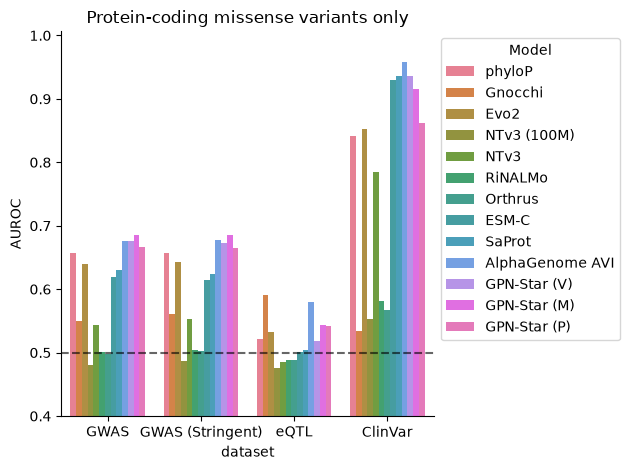

In [12]:
want_scores = [
    x
    for x in list(annot_names.keys()) + list(all_models.keys())
    if x
    not in [
        "gnomadg_af_log",
    ]
]
ms_scores = raw_score_comparison_simple(
    df,
    title="Protein-coding missense variants only",
    scores=want_scores,
)


gwas: 625 / 9726 variant-gene pairs
gwas_stringent: 422 / 7324 variant-gene pairs
eqtl: 613 / 3893 variant-gene pairs
clinvar: 8829 / 27372 variant-gene pairs


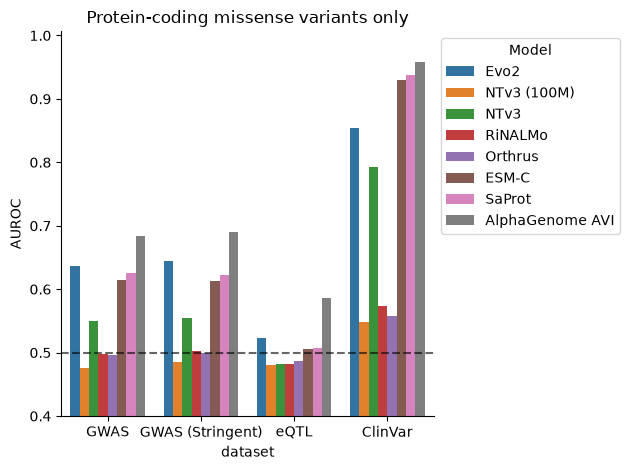

In [141]:
_ = raw_score_comparison_simple(
    df,
    title="Protein-coding missense variants only",
    scores=list(score_to_model.keys()),
)


In [142]:
df.select(**{name: pl.col(name).is_not_null().sum() for name in score_to_model})

evo_score,nt_100_score,nt_650_score,rinalmo_score,orthrus_score,esmc_score,saprot_score,alphagenome_atlas_raw_score
u32,u32,u32,u32,u32,u32,u32,u32
315327,329585,329585,329585,329585,48149,38017,329585


gwas: 625 / 9751 variant-gene pairs
gwas_stringent: 422 / 7325 variant-gene pairs
eqtl: 620 / 3938 variant-gene pairs
clinvar: 8901 / 27778 variant-gene pairs


dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""ESM-C""",0.614265,0.114439
"""GWAS""","""SaProt""",0.625427,0.111319
"""GWAS (Stringent)""","""ESM-C""",0.613244,0.107473
"""GWAS (Stringent)""","""SaProt""",0.622366,0.103752
"""eQTL""","""ESM-C""",0.505598,0.170813
"""eQTL""","""SaProt""",0.508113,0.172092
"""ClinVar""","""ESM-C""",0.930681,0.894633
"""ClinVar""","""SaProt""",0.938272,0.898905


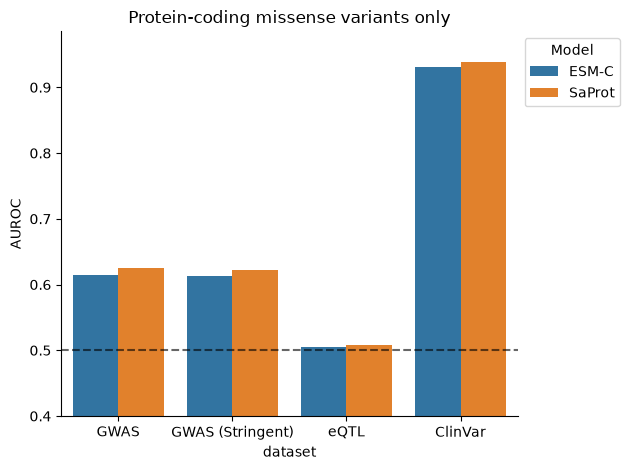

In [143]:
raw_score_comparison_simple(
    df,
    title="Protein-coding missense variants only",
    scores=["esmc_score", "saprot_score"],
)


gwas: 1132 / 80530 variant-gene pairs
gwas_stringent: 658 / 58508 variant-gene pairs
eqtl: 6261 / 49161 variant-gene pairs
clinvar: 17194 / 109170 variant-gene pairs


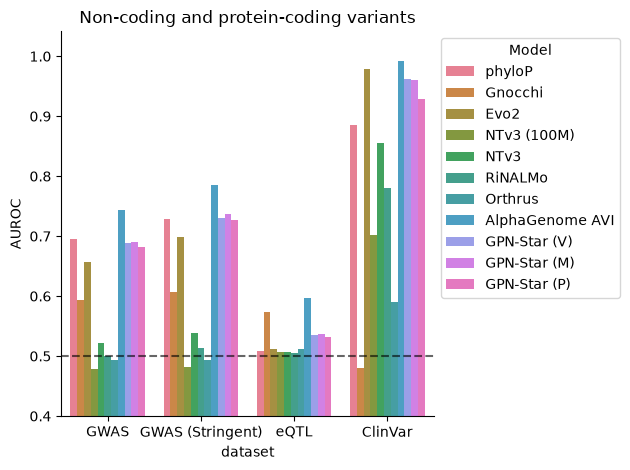

In [144]:
gw_scores = raw_score_comparison_simple(
    df,
    scores=[x for x in want_scores if x not in ["esmc_score", "saprot_score"]],
    title="Non-coding and protein-coding variants",
)

In [145]:
# Filter to chromosomes in AlphaGenome AVI test set
keep_chroms = [f"chr{x}" for x in [3, 6, 9, 12, 16, 18, 19, 21]]

avi_test_df = df.filter(pl.col("chromosome").is_in(keep_chroms))

gwas: 402 / 27262 variant-gene pairs
gwas_stringent: 235 / 20076 variant-gene pairs
eqtl: 2300 / 17569 variant-gene pairs
clinvar: 5264 / 34917 variant-gene pairs


dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""phyloP""",0.681765,0.056662
"""GWAS""","""Gnocchi""",0.600069,0.023652
"""GWAS""","""Evo2""",0.661971,0.053009
"""GWAS""","""NTv3 (100M)""",0.482658,0.01435
"""GWAS""","""NTv3""",0.530111,0.023094
"""GWAS""","""RiNALMo""",0.49935,0.015575
"""GWAS""","""Orthrus""",0.510778,0.015599
"""GWAS""","""AlphaGenome AVI""",0.725878,0.070526
"""GWAS""","""GPN-Star (V)""",0.658406,0.068887


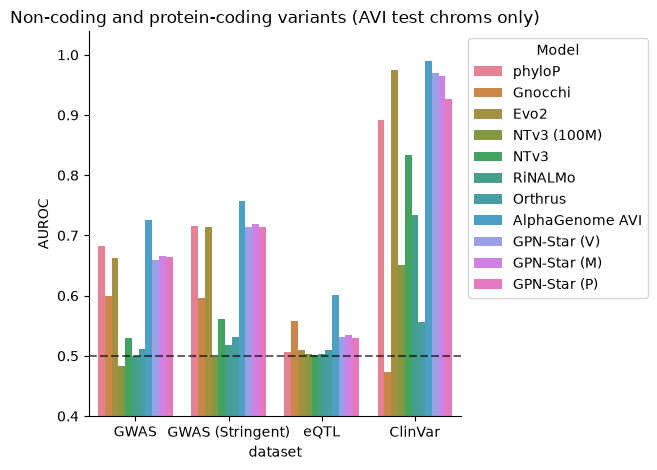

In [146]:
raw_score_comparison_simple(
    avi_test_df,
    scores=[x for x in want_scores if x not in ["esmc_score", "saprot_score"]],
    title="Non-coding and protein-coding variants (AVI test chroms only)",
)

In [147]:
gw_scores.filter(dataset="GWAS")

dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""phyloP""",0.695269,0.055937
"""GWAS""","""Gnocchi""",0.592854,0.021123
"""GWAS""","""Evo2""",0.657279,0.049486
"""GWAS""","""NTv3 (100M)""",0.478224,0.012891
"""GWAS""","""NTv3""",0.521842,0.017611
"""GWAS""","""RiNALMo""",0.500409,0.014124
"""GWAS""","""Orthrus""",0.493478,0.0136
"""GWAS""","""AlphaGenome AVI""",0.743359,0.071996
"""GWAS""","""GPN-Star (V)""",0.688495,0.064181


In [148]:
gw_scores.filter(dataset="GWAS (Stringent)")

dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS (Stringent)""","""phyloP""",0.729382,0.056452
"""GWAS (Stringent)""","""Gnocchi""",0.606934,0.017867
"""GWAS (Stringent)""","""Evo2""",0.699377,0.052249
"""GWAS (Stringent)""","""NTv3 (100M)""",0.482105,0.010499
"""GWAS (Stringent)""","""NTv3""",0.538185,0.01599
"""GWAS (Stringent)""","""RiNALMo""",0.513019,0.011797
"""GWAS (Stringent)""","""Orthrus""",0.493424,0.010941
"""GWAS (Stringent)""","""AlphaGenome AVI""",0.784507,0.076399
"""GWAS (Stringent)""","""GPN-Star (V)""",0.730295,0.067016


In [149]:
gw_scores.filter(dataset="eQTL")

dataset,score,auroc,auprc
str,str,f64,f64
"""eQTL""","""phyloP""",0.507665,0.139993
"""eQTL""","""Gnocchi""",0.573397,0.168079
"""eQTL""","""Evo2""",0.512525,0.135223
"""eQTL""","""NTv3 (100M)""",0.506429,0.124607
"""eQTL""","""NTv3""",0.506358,0.125454
"""eQTL""","""RiNALMo""",0.505695,0.125359
"""eQTL""","""Orthrus""",0.511639,0.126842
"""eQTL""","""AlphaGenome AVI""",0.596775,0.195655
"""eQTL""","""GPN-Star (V)""",0.535493,0.154823


In [150]:
combined_scores = pl.concat(
    (
        ms_scores.filter(pl.col("score").is_in(["ESM-C", "SaProt"])),
        gw_scores.filter(pl.col("score") != "NTv3 (100M)"),
    )
)
combined_scores.head()

dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""ESM-C""",0.618892,0.113225
"""GWAS""","""SaProt""",0.63085,0.111659
"""GWAS (Stringent)""","""ESM-C""",0.615005,0.109407
"""GWAS (Stringent)""","""SaProt""",0.624252,0.107095
"""eQTL""","""ESM-C""",0.500316,0.144505


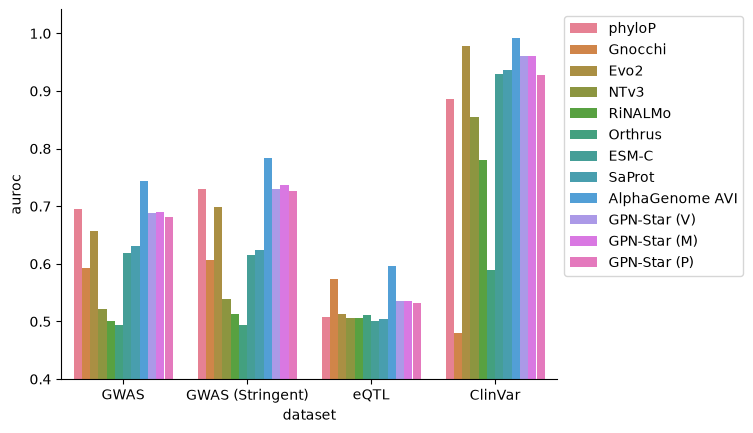

In [151]:
hue_order = [
    x
    for x in list(annot_names.values()) + list(all_models.values())
    if x not in ["NTv3 (100M)", "log(MAF)"]
]
sns.barplot(
    x="dataset",
    y="auroc",
    hue="score",
    hue_order=hue_order,
    data=combined_scores.filter(),
)
plt.ylim(0.4)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
sns.despine()

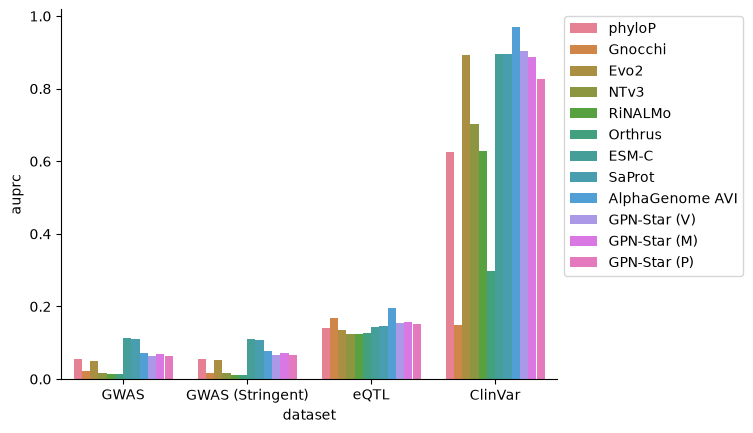

In [152]:
sns.barplot(
    x="dataset",
    y="auprc",
    hue="score",
    hue_order=hue_order,
    data=combined_scores,
)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
sns.despine()

In [153]:
combined_scores.sort("dataset", "score").filter(pl.col("dataset") != "ClinVar")

dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""AlphaGenome AVI""",0.743359,0.071996
"""GWAS""","""ESM-C""",0.618892,0.113225
"""GWAS""","""Evo2""",0.657279,0.049486
"""GWAS""","""GPN-Star (M)""",0.689687,0.068086
"""GWAS""","""GPN-Star (P)""",0.681747,0.062339
"""GWAS""","""GPN-Star (V)""",0.688495,0.064181
"""GWAS""","""Gnocchi""",0.592854,0.021123
"""GWAS""","""NTv3""",0.521842,0.017611
"""GWAS""","""Orthrus""",0.493478,0.0136


In [154]:
combined_scores.filter(pl.col("score") == "SaProt")

dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""SaProt""",0.63085,0.111659
"""GWAS (Stringent)""","""SaProt""",0.624252,0.107095
"""eQTL""","""SaProt""",0.504293,0.147357
"""ClinVar""","""SaProt""",0.93581,0.896677


In [ ]:
(
    combined_scores.filter(
        pl.col("score").is_in(
            [
                "Gnocchi",
                "phyloP",
                "Evo2",
                "GPN-Star (V)",
                "GPN-Star (M)",
                "GPN-Star (P)",
                "AlphaGenome AVI",
            ]
        ),
        pl.col("dataset") != "GWAS (Stringent)",
    ).write_csv("./tmp_scores.csv")
)


In [ ]:
(
    combined_scores.with_columns(
        modality=pl.col("score").replace(model_to_modality)
    ).write_csv("./tmp_scores.csv")
)

In [ ]:
(
    ms_scores.with_columns(
        modality=pl.col("score").replace(model_to_modality)
    ).write_csv("./ms_tmp_scores.csv")
)

In [ ]:
combined_scores.group_by("dataset").agg(pl.median("auroc"), pl.median("auprc"))

# Complementarity

Performance is defined per variant–gene pair, preserving gene-specific eQTL
labels and model scores. Cross-validation holds out entire variants, and the
paired bootstrap resamples whole variants with all their gene rows together.
Intervals condition on the fitted out-of-fold predictions.

Score-only and combined models both use degree-two polynomial features.


In [13]:
def prepare_labeled_data(
    data: pl.DataFrame,
    feature_cols: list[str],
    label_columns: list[str],
) -> pl.DataFrame:
    """Collapse labels to single binary 0/1 labels."""
    return data.filter(
        pl.all_horizontal(pl.col(feature_cols).is_not_null()),
        pl.any_horizontal(pl.col(label_columns).is_not_null()),
    ).with_columns(
        label=pl.any_horizontal(
            (pl.col(label_columns) == "high_pip").fill_null(False),
            (pl.col(label_columns).str.contains("athogenic")).fill_null(False),
        ).cast(pl.Int8),
    )


def select_biotype_group(
    data: pl.DataFrame,
    biotype: Literal["all", "protein_coding", "lncRNA"],
) -> pl.DataFrame:
    return data if biotype == "all" else data.filter(pl.col("biotype") == biotype)


def cv_eval_models(
    full_data: pl.DataFrame,
    label_cols: list[str],
    models: dict[str, Any],
    cv: StratifiedGroupKFold,
) -> tuple[pl.DataFrame, np.ndarray, dict[str, np.ndarray], np.ndarray]:
    # All paired comparisons must use the same variant-gene rows and folds.
    all_features = list(
        dict.fromkeys(feat for features, _ in models.values() for feat in features)
    )
    labeled_data = prepare_labeled_data(full_data, all_features, label_cols)
    groups = labeled_data.get_column("variant").to_numpy()
    y = labeled_data.get_column("label").to_numpy()
    splits = list(cv.split(labeled_data, y, groups))

    predictions = {}
    metrics = []
    for model_name, (features, model) in models.items():
        prediction = cross_val_predict(
            model,
            labeled_data.select(features).to_numpy(),
            y,
            cv=splits,
            method="predict_proba",
            n_jobs=2,
        )[:, 1]
        predictions[model_name] = prediction
        metrics.append(
            {
                "model": model_name,
                "auroc": roc_auc_score(y, prediction),
                "auprc": average_precision_score(y, prediction),
            }
        )
    return pl.DataFrame(metrics), y, predictions, groups


def eval_all_datasets(
    full_data: pl.DataFrame,
    dataset_specs: dict[str, list[str]],
    want_biotypes: list[str],
    model_specs: dict[str, Any],
    n_folds: int = 5,
) -> tuple[
    pl.DataFrame,
    dict[tuple[str, str], dict[str, np.ndarray]],
    dict[tuple[str, str], np.ndarray],
    dict[tuple[str, str], np.ndarray],
]:
    complementarity_cv = StratifiedGroupKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=42,
    )

    oof_predictions = {}
    oof_outcomes = {}
    oof_groups = {}
    model_metrics = []
    for dataset, label_columns in dataset_specs.items():
        for biotype in want_biotypes:
            data = select_biotype_group(full_data, biotype)
            metrics, _y, _predictions, _groups = cv_eval_models(
                full_data=data,
                label_cols=label_columns,
                models=model_specs,
                cv=complementarity_cv,
            )
            key = (dataset, biotype)
            oof_outcomes[key] = _y
            oof_groups[key] = _groups
            oof_predictions[key] = _predictions
            model_metrics.append(
                metrics.with_columns(dataset=pl.lit(dataset), biotype=pl.lit(biotype))
            )
    model_metrics = pl.concat(model_metrics).sort(
        "dataset", "biotype", "auroc", descending=[False, False, True]
    )
    return model_metrics, oof_predictions, oof_outcomes, oof_groups


In [14]:
dataset_specs = {
    "GWAS": ["ukbb_label", "multisusie_label"],
    "eQTL": ["eqtl_label"],
    "All": ["ukbb_label", "multisusie_label", "eqtl_label"],
    "ClinVar": ["clinvar_label"],
}
analysis_biotypes = ["all", "protein_coding", "lncRNA"]

group_sizes = pl.DataFrame(
    [
        {
            "dataset": _dataset,
            "biotype": _biotype,
            "variant_gene_pairs": len(_data),
            "variants": _data.get_column("variant").n_unique(),
            "high_pip": _data.get_column("label").sum(),
            "low_pip": len(_data) - _data.get_column("label").sum(),
        }
        for _dataset, _label_columns in dataset_specs.items()
        for _biotype in analysis_biotypes
        for _data in [
            select_biotype_group(
                prepare_labeled_data(df, ["phylop", "gnocchi_z"], _label_columns),
                _biotype,
            )
        ]
    ]
)
group_sizes

dataset,biotype,variant_gene_pairs,variants,high_pip,low_pip
str,str,i64,i64,i64,i64
"""GWAS""","""all""",80877,78970,1133,79744
"""GWAS""","""protein_coding""",52931,51813,906,52025
"""GWAS""","""lncRNA""",27946,27157,227,27719
"""eQTL""","""all""",49988,49575,6440,43548
"""eQTL""","""protein_coding""",34597,34328,3864,30733
"""eQTL""","""lncRNA""",15391,15247,2576,12815
"""All""","""all""",114813,112637,7483,107330
"""All""","""protein_coding""",75393,74119,4698,70695
"""All""","""lncRNA""",39420,38518,2785,36635


In [15]:
lr_cv_params = {
    "l1_ratios": (0.0,),
    "scoring": "neg_log_loss",
    "use_legacy_attributes": False,
    "n_jobs": 8,
}

quadratic_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LogisticRegressionCV(**lr_cv_params),
)


def model_to_specs(score_name: str) -> dict[str, Any]:
    shorthand = score_name.replace("_score", "")
    return {
        f"{shorthand}_gnocchi": (
            [score_name, "gnocchi_z"],
            quadratic_model,
        ),
        f"{shorthand}_phylop": ([score_name, "phylop"], quadratic_model),
        f"{shorthand}_gnocchi_phylop": (
            [score_name, "gnocchi_z", "phylop"],
            quadratic_model,
        ),
    }


model_specs = {
    "PhyloP": (["phylop"], quadratic_model),
    "Gnocchi": (["gnocchi_z"], quadratic_model),
}

for score_name, pretty_name in all_models.items():
    model_specs.update({pretty_name: ([score_name], quadratic_model)})
    model_specs.update(model_to_specs(score_name))

In [16]:
# New cache namespace: old linear-baseline / row-bootstrap results are invalid.
classification_dir = (
    project_dir / "classification" / "quadratic_variant_bootstrap_filtered_ukbb"
)
classification_dir.mkdir(parents=True, exist_ok=True)

# Set True after regenerating upstream UKBB curation/annotations or changing inputs.
regen = False

In [17]:
# Missense variants only, due to inclusion of ESM-C as a model
ms_regen = regen or not (classification_dir / "missense_preds.pkl").exists()
if ms_regen:
    ms_perf_metrics, ms_all_preds, ms_all_labels, ms_all_groups = eval_all_datasets(
        full_data=df,
        dataset_specs=dataset_specs,
        want_biotypes=["all"],
        model_specs=model_specs,
    )

    with open(
        classification_dir / "missense_preds.pkl",
        "wb",
    ) as fh:
        dump((ms_perf_metrics, ms_all_preds, ms_all_labels, ms_all_groups), fh)

else:
    with open(
        classification_dir / "missense_preds.pkl",
        "rb",
    ) as fh:
        ms_perf_metrics, ms_all_preds, ms_all_labels, ms_all_groups = load(fh)

ms_perf_metrics.head()

model,auroc,auprc,dataset,biotype
str,f64,f64,str,str
"""gpn_star_m_gnocchi""",0.607468,0.130812,"""All""","""all"""
"""gpn_star_m_gnocchi_phylop""",0.603475,0.128532,"""All""","""all"""
"""GPN-Star (M)""",0.602723,0.128948,"""All""","""all"""
"""alphagenome_atlas_raw_gnocchi""",0.60249,0.135636,"""All""","""all"""
"""alphagenome_atlas_raw_gnocchi_…",0.600676,0.133261,"""All""","""all"""


In [18]:
# All variants, excluding ESM-C and SaProt as a model
gw_regen = regen or not (classification_dir / "genome_wide_preds.pkl").exists()
if gw_regen:
    gw_specs = {}
    for name, spec in model_specs.items():
        if "esm" in name.lower() or "saprot" in name.lower():
            continue
        gw_specs[name] = spec

    gw_perf_metrics, gw_all_preds, gw_all_labels, gw_all_groups = eval_all_datasets(
        full_data=df,
        dataset_specs=dataset_specs,
        want_biotypes=["all"],
        model_specs=gw_specs,
    )
    with open(
        classification_dir / "genome_wide_preds.pkl",
        "wb",
    ) as fh:
        dump((gw_perf_metrics, gw_all_preds, gw_all_labels, gw_all_groups), fh)

else:
    with open(
        classification_dir / "genome_wide_preds.pkl",
        "rb",
    ) as fh:
        gw_perf_metrics, gw_all_preds, gw_all_labels, gw_all_groups = load(fh)

gw_perf_metrics.head()

model,auroc,auprc,dataset,biotype
str,f64,f64,str,str
"""alphagenome_atlas_raw_gnocchi_…",0.634509,0.113383,"""All""","""all"""
"""alphagenome_atlas_raw_phylop""",0.624623,0.111466,"""All""","""all"""
"""alphagenome_atlas_raw_gnocchi""",0.613983,0.103277,"""All""","""all"""
"""AlphaGenome AVI""",0.599476,0.100864,"""All""","""all"""
"""gpn_star_v_gnocchi""",0.579789,0.089847,"""All""","""all"""


In [19]:
def variant_bootstrap_weights(
    group_indices: np.ndarray,
    rng: np.random.RandomState,
) -> np.ndarray:
    """Draw variants uniformly; every gene row inherits its variant's multiplicity.

    group_indices contains dense variant codes from np.unique(return_inverse=True).
    Integer metric weights exactly represent repeating all rows of each drawn variant.
    """
    n_groups = int(group_indices.max()) + 1
    draws = rng.randint(n_groups, size=n_groups)
    counts = np.bincount(draws, minlength=n_groups)
    return counts[group_indices]


def sample_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    group_indices: np.ndarray,
    job_idx: int,
    num_bootstraps: int = 100,
) -> dict[str, list[float]]:
    """Variant-cluster bootstrap estimates of pair-level AUROC and AUPRC."""
    rng = np.random.RandomState(seed=42 + job_idx)
    results = defaultdict(list)
    for _ in range(num_bootstraps):
        weights = variant_bootstrap_weights(group_indices, rng)
        results["auroc"].append(roc_auc_score(y_true, y_pred, sample_weight=weights))
        results["auprc"].append(
            average_precision_score(y_true, y_pred, sample_weight=weights)
        )
    return results


def sample_metric_deltas(
    y_pred_ref: np.ndarray,
    y_pred_oth: np.ndarray,
    y_true: np.ndarray,
    group_indices: np.ndarray,
    job_idx: int,
    num_bootstraps: int = 100,
) -> dict[str, list[float]]:
    """Paired variant-cluster bootstrap of pair-level performance differences."""
    rng = np.random.RandomState(seed=42 + job_idx)
    results = defaultdict(list)
    for _ in range(num_bootstraps):
        weights = variant_bootstrap_weights(group_indices, rng)
        auroc_ref = roc_auc_score(y_true, y_pred_ref, sample_weight=weights)
        auroc_oth = roc_auc_score(y_true, y_pred_oth, sample_weight=weights)
        results["auroc"].append(auroc_oth - auroc_ref)
        results["auroc_pct"].append(100 * (auroc_oth - auroc_ref) / auroc_ref)

        auprc_ref = average_precision_score(y_true, y_pred_ref, sample_weight=weights)
        auprc_oth = average_precision_score(y_true, y_pred_oth, sample_weight=weights)
        results["auprc"].append(auprc_oth - auprc_ref)
        results["auprc_pct"].append(100 * (auprc_oth - auprc_ref) / auprc_ref)
    return results


def nested_metrics_to_df(
    x: list[dict[str, list[float]]],
    index_items: dict[str, str],
) -> pl.DataFrame:
    flat = defaultdict(list)
    for d in x:
        for k, values in d.items():
            flat[k].extend(values)
    flat.update(index_items)
    return pl.DataFrame(flat)


def run_bootstrap_estimates(
    preds: dict[tuple[str, str], dict[str, np.ndarray]],
    labels: dict[tuple[str, str], np.ndarray],
    groups: dict[tuple[str, str], np.ndarray],
    comparisons: list[tuple[str, tuple[str, ...]]],
    n_jobs: int = 8,
    num_bootstraps_per_job: int = 100,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    seen = set()
    bootstrapped_metrics = []
    bootstrapped_diffs = []

    with Pool(processes=n_jobs) as p:
        for key, y_true in labels.items():
            dataset, biotype = key
            _, group_indices = np.unique(groups[key], return_inverse=True)
            index = {"dataset": dataset, "biotype": biotype}
            for ref_model, compare_models in comparisons:
                y_ref = preds[key][ref_model]
                for model in dict.fromkeys((ref_model, *compare_models)):
                    if (key, model) in seen:
                        continue
                    metric_func = partial(
                        sample_metrics,
                        y_true,
                        preds[key][model],
                        group_indices,
                        num_bootstraps=num_bootstraps_per_job,
                    )
                    bootstrapped_metrics.append(
                        nested_metrics_to_df(
                            x=p.map(metric_func, range(n_jobs)),
                            index_items={"model": model, **index},
                        )
                    )
                    seen.add((key, model))

                for compare_model in compare_models:
                    metric_func = partial(
                        sample_metric_deltas,
                        y_ref,
                        preds[key][compare_model],
                        y_true,
                        group_indices,
                        num_bootstraps=num_bootstraps_per_job,
                    )
                    bootstrapped_diffs.append(
                        nested_metrics_to_df(
                            x=p.map(metric_func, range(n_jobs)),
                            index_items={
                                "ref": ref_model,
                                "compare": compare_model,
                                **index,
                            },
                        )
                    )
    return pl.concat(bootstrapped_metrics), pl.concat(bootstrapped_diffs)


In [20]:
def make_comparison_lists(
    want_references: list[str],
) -> list[tuple]:
    ret = []
    pretty_to_score = {v: k for k, v in all_models.items()}

    for ref in want_references:
        shorthand = pretty_to_score[ref].replace("_score", "")
        ret.append(
            (
                ref,
                (
                    f"{shorthand}_phylop",
                    f"{shorthand}_gnocchi",
                    f"{shorthand}_gnocchi_phylop",
                ),
            )
        )
    return ret


ms_delta_comparisons = make_comparison_lists(want_references=list(all_models.values()))
gw_delta_comparisons = make_comparison_lists(
    want_references=[x for x in all_models.values() if x not in ["ESM-C", "SaProt"]],
)

In [21]:
if ms_regen or not (classification_dir / "missense_bootstraps.pkl").exists():
    ms_bootstrap_metrics, ms_bootstrap_diffs = run_bootstrap_estimates(
        preds=ms_all_preds,
        labels=ms_all_labels,
        groups=ms_all_groups,
        comparisons=ms_delta_comparisons,
    )
    with open(
        classification_dir / "missense_bootstraps.pkl",
        "wb",
    ) as fh:
        dump((ms_bootstrap_metrics, ms_bootstrap_diffs), fh)

else:
    with open(
        classification_dir / "missense_bootstraps.pkl",
        "rb",
    ) as fh:
        ms_bootstrap_metrics, ms_bootstrap_diffs = load(fh)

ms_bootstrap_metrics.head()

auroc,auprc,model,dataset,biotype
f64,f64,str,str,str
0.604068,0.082312,"""Evo2""","""GWAS""","""all"""
0.650908,0.091879,"""Evo2""","""GWAS""","""all"""
0.644722,0.108354,"""Evo2""","""GWAS""","""all"""
0.644018,0.098856,"""Evo2""","""GWAS""","""all"""
0.620053,0.093554,"""Evo2""","""GWAS""","""all"""


In [22]:
if gw_regen or not (classification_dir / "genome_wide_bootstraps.pkl").exists():
    gw_bootstrap_metrics, gw_bootstrap_diffs = run_bootstrap_estimates(
        preds=gw_all_preds,
        labels=gw_all_labels,
        groups=gw_all_groups,
        comparisons=gw_delta_comparisons,
    )
    with open(
        classification_dir / "genome_wide_bootstraps.pkl",
        "wb",
    ) as fh:
        dump((gw_bootstrap_metrics, gw_bootstrap_diffs), fh)

else:
    with open(
        classification_dir / "genome_wide_bootstraps.pkl",
        "rb",
    ) as fh:
        gw_bootstrap_metrics, gw_bootstrap_diffs = load(fh)

gw_bootstrap_metrics.head()

auroc,auprc,model,dataset,biotype
f64,f64,str,str,str
0.654292,0.047136,"""Evo2""","""GWAS""","""all"""
0.650054,0.048708,"""Evo2""","""GWAS""","""all"""
0.669588,0.054066,"""Evo2""","""GWAS""","""all"""
0.670441,0.050807,"""Evo2""","""GWAS""","""all"""
0.653507,0.046677,"""Evo2""","""GWAS""","""all"""


In [23]:
gw_bootstrap_diffs.head()

auroc,auroc_pct,auprc,auprc_pct,ref,compare,dataset,biotype
f64,f64,f64,f64,str,str,str,str
0.0407,6.220459,0.007814,16.578557,"""Evo2""","""evo_phylop""","""GWAS""","""all"""
0.055986,8.612553,0.015025,30.846371,"""Evo2""","""evo_phylop""","""GWAS""","""all"""
0.034463,5.146862,0.011726,21.688358,"""Evo2""","""evo_phylop""","""GWAS""","""all"""
0.039914,5.953428,0.011781,23.187901,"""Evo2""","""evo_phylop""","""GWAS""","""all"""
0.04699,7.19043,0.016377,35.085492,"""Evo2""","""evo_phylop""","""GWAS""","""all"""


### Plots

In [ ]:
def feature_list_to_sort_key(
    features: list[str],
    feature_order: list[str],
) -> int:
    return sum([2 ** feature_order.index(x) for x in features])


def plot_feature_comparison(
    data: pl.DataFrame,
    plot_col: str,
    ax: plt.Axes,
    ax_sets: plt.Axes,
    feature_order: list[str],
    title: str | None = None,
    modality: str | None = None,
    annotate_col: str | None = None,
):
    """Plot performance bars and corresponding UpSet-style feature matrix."""
    # Restrict to comparisons where all features are in the desired feature set
    specs_to_features = {k: v[0] for k, v in model_specs.items()}
    data = (
        data.with_columns(
            feature_set=pl.col("compare").replace_strict(
                specs_to_features, return_dtype=pl.List
            ),
        )
        .filter(
            pl.col("feature_set").list.set_difference(feature_order).list.len() == 0,
        )
        .drop("feature_set")
    )

    names_and_features = sorted(
        [(name, model_specs[name][0]) for name in data.get_column("compare").unique()],
        key=lambda x: feature_list_to_sort_key(x[1], feature_order),
    )
    names, feature_sets = zip(*names_and_features)
    common_kwargs = {
        "x": "compare",
        "order": names,
        "estimator": np.mean,
        "errorbar": ("pi", 95),
        "data": data,
    }
    if modality is not None:
        common_kwargs["facecolor"] = modality_colors[modality]

    # Performance
    sns.barplot(
        y=plot_col,
        ax=ax,
        alpha=0.7,
        edgecolor="black",
        **common_kwargs,
    )
    if annotate_col is not None:
        values = (
            data.group_by("compare")
            .agg(value=pl.col(annotate_col).mean())
            .rows_by_key(key="compare")
        )
        for bar, name in zip(ax.patches, names):
            value = values[name][0][0]
            fontsize = plt.rcParams["font.size"] * 0.9

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                0.02,
                rf"{value:+0.3f}",
                ha="center",
                va="bottom",
                transform=ax.get_xaxis_transform(),
                fontsize=fontsize,
            )

    ax.set_title(title or "")
    ax.set_xlabel("")
    ax.axhline(0, color="0.5", lw=0.75)

    # Feature matrix
    for i, feature_set in enumerate(feature_sets):
        included = set(feature_set)

        for j, feature in enumerate(feature_order):
            feat_name = annot_names.get(feature, "other")
            pos_color = annot_colors.get(feat_name, "dimgray")
            ax_sets.scatter(
                i,
                j,
                s=45,
                facecolor=pos_color if feature in included else "white",
                edgecolor="dimgray",
            )
    ax.set_xlim(-0.5, len(names) - 0.5)
    ax_sets.set_xlim(-0.5, len(names) - 0.5)

    ax_sets.set(
        ylim=(-0.5, len(feature_order) - 0.5),
        xticks=[],
        yticks=range(len(feature_order)),
    )
    ax_sets.invert_yaxis()
    ax_sets.tick_params(axis="y", length=0)

    sns.despine(ax=ax)
    sns.despine(ax=ax_sets, left=True, bottom=True)

In [105]:
def diffs_upset_plot_by_modality(
    bootstrap_diffs: pl.DataFrame,
    dataset: str,
    feature_order: list[str] | None = ["phylop", "gnocchi_z"],
    want_refs: list[str] | None = None,
    plot_col: str = "auroc_pct",
    show_title: bool = True,
    sharey: bool = False,
    ymin: float | None = None,
):
    plot_data = bootstrap_diffs.filter(pl.col("dataset") == dataset)
    if want_refs is None:
        want_refs = plot_data["ref"].unique().sort().to_list()

    # Determine global feature ordering
    all_names = plot_data["compare"].unique()
    if feature_order is None:
        feature_counts = Counter(f for name in all_names for f in model_specs[name][0])
        feature_order = [
            f for f, _ in feature_counts.most_common() if f not in score_to_model
        ]

    model_to_score_name = {v: k for k, v in score_to_model.items()}

    model_modalities = defaultdict(list)
    for ref in want_refs:
        model_modalities[model_to_modality[ref]].append(ref)

    for modality, models in model_modalities.items():
        if len(models) != 2:
            raise ValueError(
                f"expected exactly 2 models per modality, got: {modality} = {len(models)}"
            )

    _, axs = plt.subplots(
        5,
        len(model_modalities),
        figsize=(4 * len(model_modalities), 8),
        # sharex="col",
        sharex=False,
        gridspec_kw={
            "height_ratios": [4, 1, 0.01, 4, 1],
            "hspace": 0.15,
            "wspace": 0.5,
        },
        squeeze=False,
    )

    # Empty spacer row
    for ax in axs[2]:
        ax.axis("off")

    j = 0
    first_bar_ax = None
    for j, modality in enumerate(models_by_modality):
        if modality not in model_modalities:
            continue
        models = model_modalities[modality]

        for i, ref in enumerate(models):
            if ref != "phyloP":
                this_feature_order = [model_to_score_name[ref]] + feature_order
            else:
                this_feature_order = ["phylop"] + [
                    x for x in feature_order if x != "phylop"
                ]

            if i == 0:
                bar_ax = axs[0, j]
                set_ax = axs[1, j]
            else:
                bar_ax = axs[3, j]
                set_ax = axs[4, j]

            if sharey and first_bar_ax is not None:
                bar_ax.sharey(first_bar_ax)

            title = f"{modality} models" if i == 0 else ""
            plot_feature_comparison(
                plot_data.filter(pl.col("ref") == ref),
                plot_col=plot_col,
                annotate_col="auroc",
                ax=bar_ax,
                ax_sets=set_ax,
                feature_order=this_feature_order,
                title=title,
                modality=modality,
            )
            bar_ax.set_xticklabels([])
            bar_ax.set_xticks([])
            bar_ax.set_ylabel("")

            set_ax.set_yticklabels(
                [pretty_names.get(f, "") for f in this_feature_order]
            )

            # If we're sharing y-axes, want to hide the labels from
            # the first and last columns for the original and twinned
            # axes respectively
            if sharey:
                if first_bar_ax is None:
                    first_bar_ax = bar_ax

                if j != 0:
                    bar_ax.tick_params(axis="y", labelleft=False)

    if ymin is not None:
        first_bar_ax.set_ylim(bottom=ymin)
    # ymin, _ = first_bar_ax.get_ylim()
    # first_bar_ax.set_ylim(bottom=ymin * 1.75)

    label = ""
    if plot_col == "auroc":
        label = r"$\Delta$ AUROC"
    elif plot_col == "auroc_pct":
        label = "% AUROC change"
    elif plot_col == "auprc":
        label = r"$\Delta$ AUPRC"
    elif plot_col == "auprc_pct":
        label = "% AUPRC change"

    axs[0, 0].set_ylabel(label)
    axs[3, 0].set_ylabel(label)

    plt.tight_layout()
    if show_title:
        plt.suptitle(f"Dataset = {dataset}")

In [124]:
def diffs_upset_plot_simple(
    bootstrap_diffs: pl.DataFrame,
    dataset: str,
    feature_order: list[str] | None = ["phylop", "gnocchi_z"],
    want_refs: list[str] | None = None,
    plot_col: str = "auroc_pct",
    annotate_col: str | None = None,
    show_title: bool = True,
    sharey: bool = False,
    ymin: float | None = None,
):
    plot_data = bootstrap_diffs.filter(pl.col("dataset") == dataset)
    if want_refs is None:
        want_refs = plot_data["ref"].unique().sort().to_list()

    model_to_score_name = {v: k for k, v in all_models.items()}

    _, axs = plt.subplots(
        2,
        len(want_refs),
        figsize=(4 * len(want_refs), 4),
        # sharex="col",
        sharex=False,
        gridspec_kw={
            "height_ratios": [4, 1],
            "hspace": 0.15,
            "wspace": 0.5,
        },
        squeeze=False,
    )

    first_bar_ax = None
    for j, ref in enumerate(want_refs):
        if ref != "phyloP":
            this_feature_order = [model_to_score_name[ref]] + feature_order
        else:
            this_feature_order = ["phylop"] + [
                x for x in feature_order if x != "phylop"
            ]

        bar_ax = axs[0, j]
        set_ax = axs[1, j]

        if sharey and first_bar_ax is not None:
            bar_ax.sharey(first_bar_ax)

        plot_feature_comparison(
            plot_data.filter(pl.col("ref") == ref),
            plot_col=plot_col,
            annotate_col=annotate_col,
            ax=bar_ax,
            ax_sets=set_ax,
            feature_order=this_feature_order,
            title="",
            modality="DNA",
        )
        bar_ax.set_xticklabels([])
        bar_ax.set_xticks([])
        bar_ax.set_ylabel("")

        model_names = [pretty_names.get(f, "") for f in this_feature_order]
        if "AVI" in ref:
            model_names = ["AVI"] + model_names[1:]

        set_ax.set_yticklabels(model_names)

        # If we're sharing y-axes, want to hide the labels from
        # the first and last columns for the original and twinned
        # axes respectively
        if sharey:
            if first_bar_ax is None:
                first_bar_ax = bar_ax

            if j != 0:
                bar_ax.tick_params(axis="y", labelleft=False)

    if ymin is not None:
        first_bar_ax.set_ylim(bottom=ymin)

    label = ""
    if plot_col == "auroc":
        label = r"$\Delta$ AUROC"
    elif plot_col == "auroc_pct":
        label = "% AUROC change"
    elif plot_col == "auprc":
        label = r"$\Delta$ AUPRC"
    elif plot_col == "auprc_pct":
        label = "% AUPRC change"

    axs[0, 0].set_ylabel(label)
    plt.tight_layout()
    if show_title:
        plt.suptitle(f"Dataset = {dataset}")


#### AG and GPN-Star

/tmp/ipykernel_177709/3413502012.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


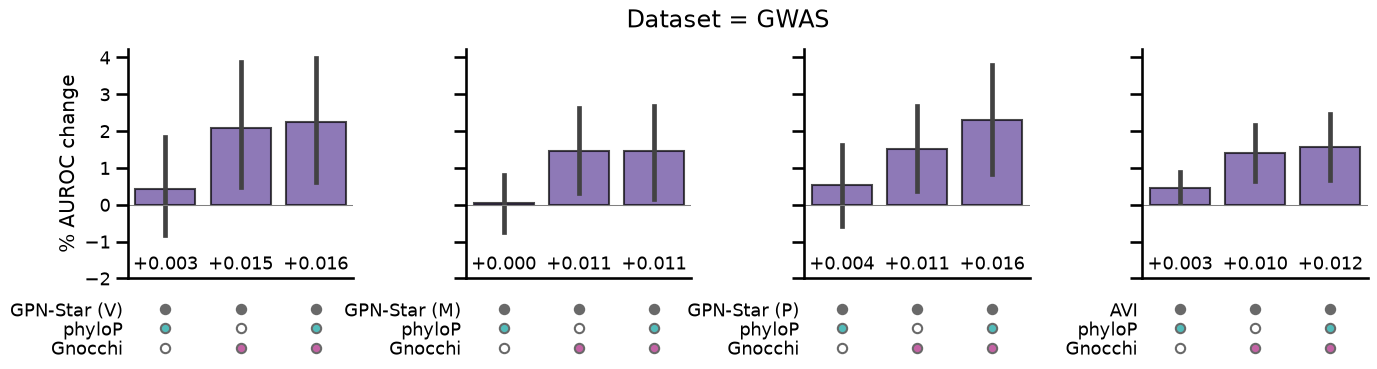

In [130]:
# with sns.plotting_context("talk", font_scale=0.8):
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_simple(
        gw_bootstrap_diffs,
        "GWAS",
        want_refs=[
            "GPN-Star (V)",
            "GPN-Star (M)",
            "GPN-Star (P)",
            "AlphaGenome AVI",
        ],
        plot_col="auroc_pct",
        annotate_col="auroc",
        sharey=True,
        ymin=-2,
    )
    save_fig("app_fig_oth_complementarity_gwas.pdf")


/tmp/ipykernel_177709/3413502012.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


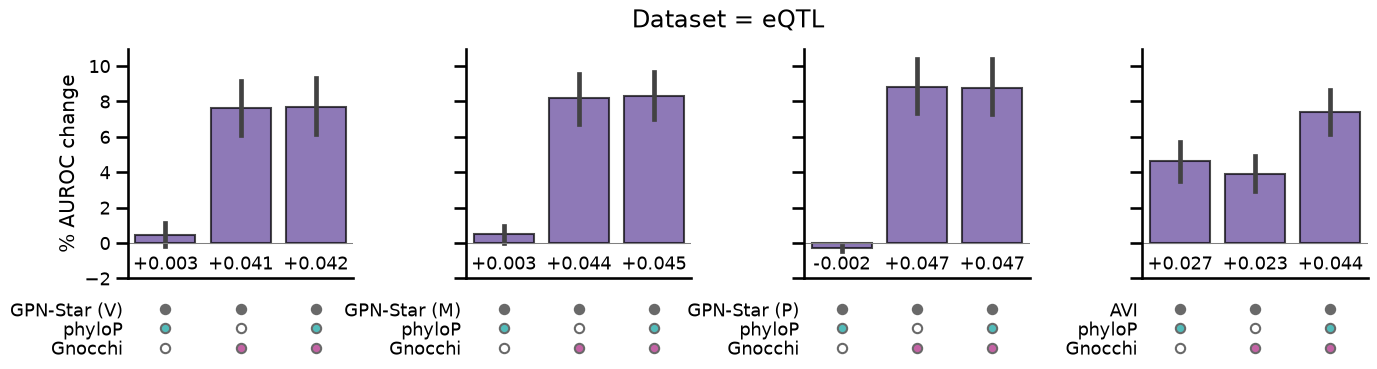

In [131]:
# with sns.plotting_context("talk", font_scale=0.8):
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_simple(
        gw_bootstrap_diffs,
        "eQTL",
        want_refs=[
            "GPN-Star (V)",
            "GPN-Star (M)",
            "GPN-Star (P)",
            "AlphaGenome AVI",
        ],
        plot_col="auroc_pct",
        annotate_col="auroc",
        sharey=True,
        ymin=-2,
    )
    save_fig("app_fig_oth_complementarity_eqtl.pdf")


/tmp/ipykernel_177709/3413502012.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


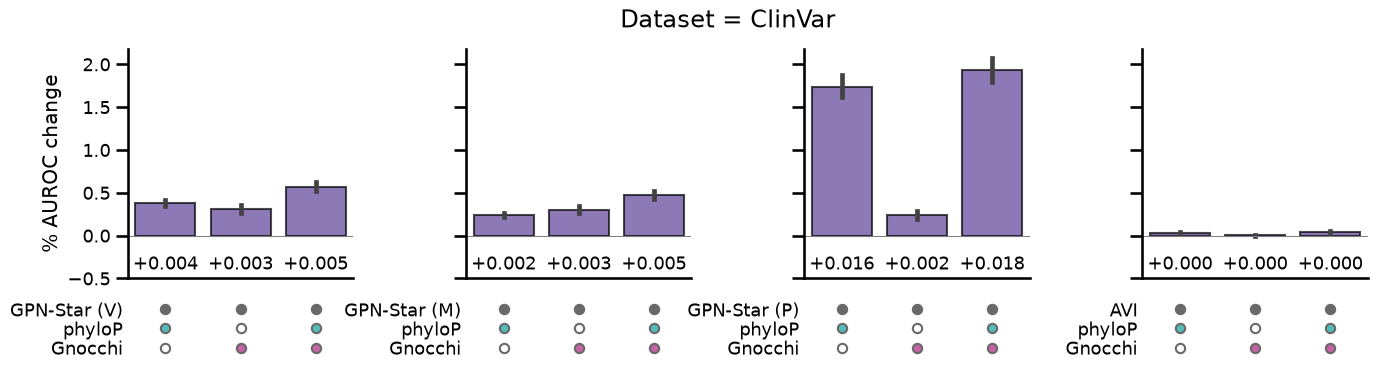

In [135]:
# with sns.plotting_context("talk", font_scale=0.8):
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_simple(
        gw_bootstrap_diffs,
        "ClinVar",
        want_refs=[
            "GPN-Star (V)",
            "GPN-Star (M)",
            "GPN-Star (P)",
            "AlphaGenome AVI",
        ],
        plot_col="auroc_pct",
        annotate_col="auroc",
        sharey=True,
        ymin=-0.5,
    )
    save_fig("app_fig_oth_complementarity_clinvar.pdf")


## Combined comparisons

In [107]:
combined_diffs = pl.concat(
    (
        ms_bootstrap_diffs.filter(pl.col("ref").is_in(models_by_modality["Protein"])),
        gw_bootstrap_diffs.filter(
            ~pl.col("ref").is_in(models_by_modality["Protein"])
        ).with_columns(ref=pl.col("ref").replace({"NTv3 (650M)": "NTv3"})),
    )
).with_columns(modality=pl.col("ref").replace(model_to_modality))

/tmp/ipykernel_177709/3223228119.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


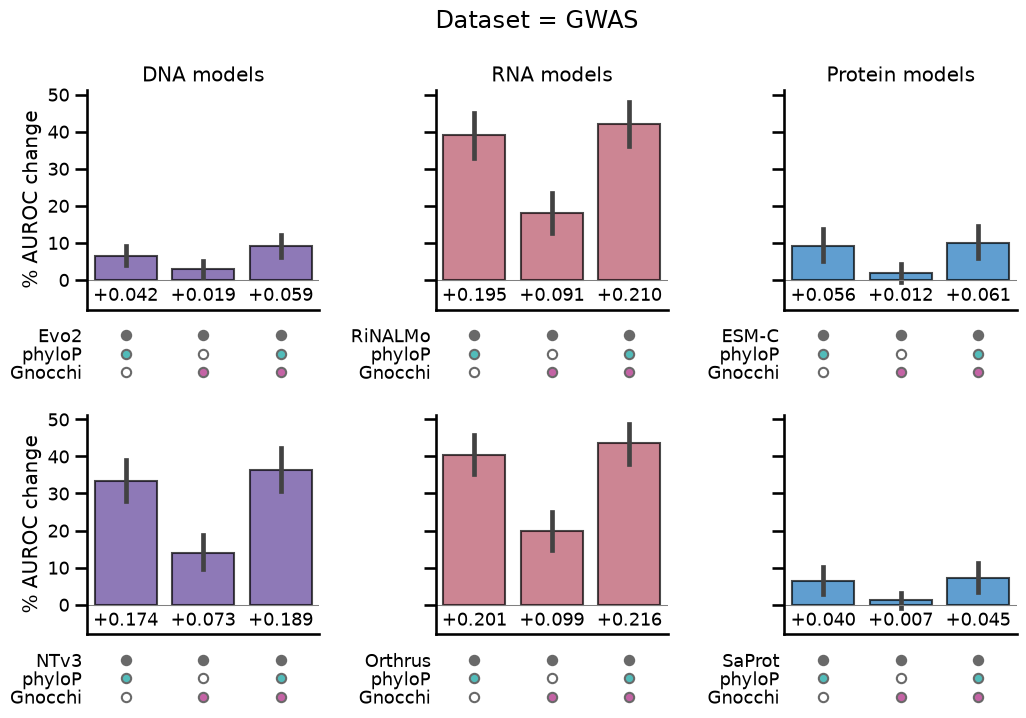

In [108]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        combined_diffs,
        "GWAS",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
        sharey=True,
        ymin=-8,
    )
    save_fig("app_fig_complementarity_gwas.pdf")


/tmp/ipykernel_177709/3223228119.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


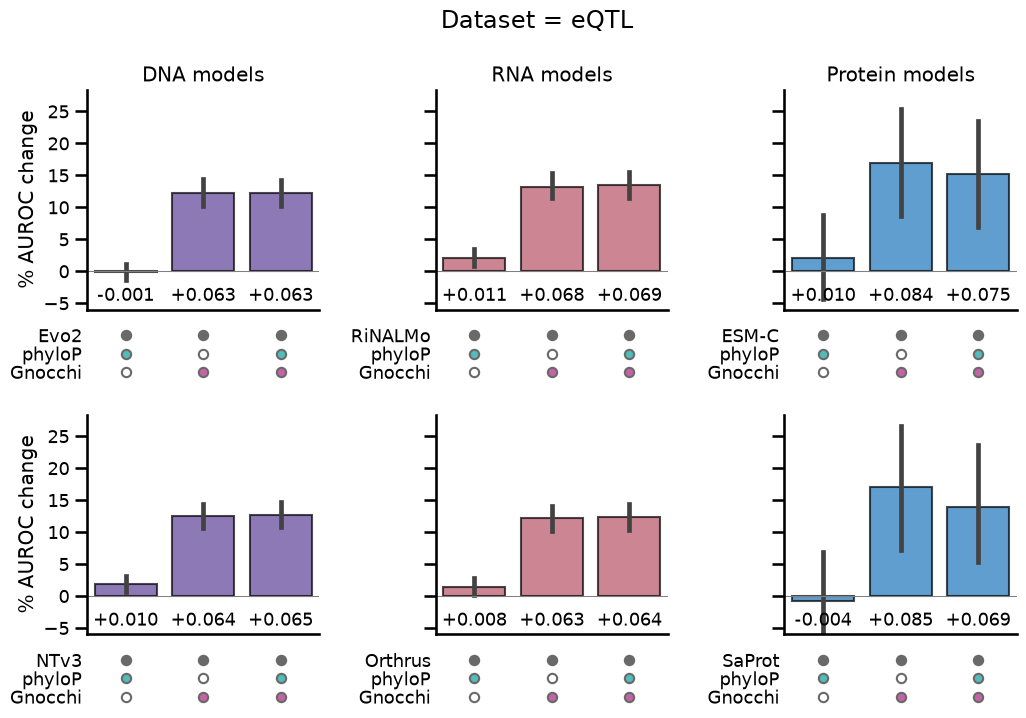

In [109]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        combined_diffs,
        "eQTL",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
        sharey=True,
        ymin=-6,
    )
    save_fig("app_fig_complementarity_eqtl.pdf")

/tmp/ipykernel_177709/3223228119.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


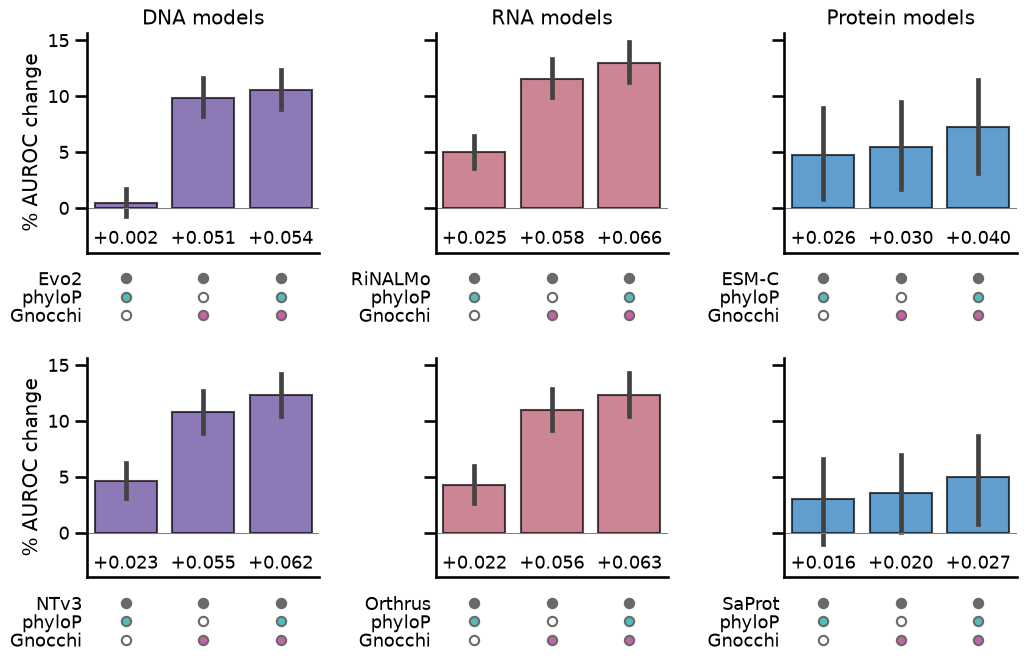

In [114]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        combined_diffs,
        "All",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
        show_title=False,
        sharey=True,
        ymin=-4,
    )

    save_fig("fig4_complementarity_eqtl_gwas.pdf")

/tmp/ipykernel_177709/3223228119.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


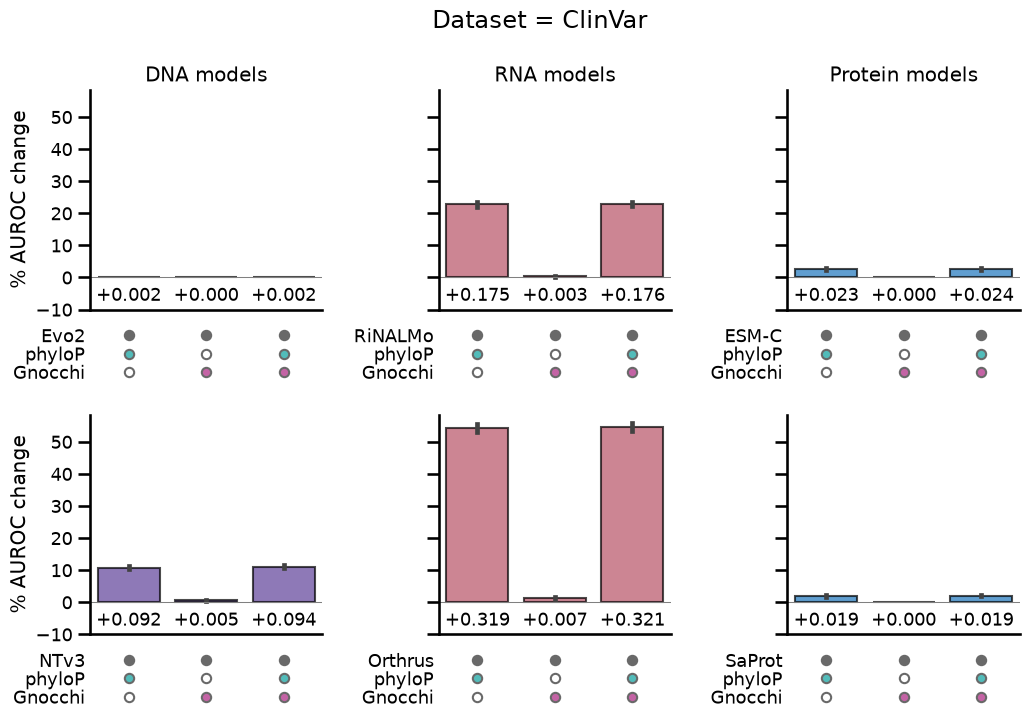

In [117]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        combined_diffs,
        "ClinVar",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
        show_title=True,
        sharey=True,
        ymin=-10,
    )

    save_fig("app_fig_complementarity_clinvar.pdf")

### Summary per approach

In [ ]:
(
    combined_diffs.filter(
        pl.col("dataset").is_in(("eQTL", "GWAS")),
        pl.col("ref") != "NTv3 (100M)",
    )
    .group_by("modality", "compare")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(pl.col("compare").str.ends_with("_gnocchi"))
    .sort("modality")
)

In [ ]:
(
    combined_diffs.filter(
        pl.col("dataset").is_in(("eQTL", "GWAS")),
        pl.col("ref") != "NTv3 (100M)",
    )
    .group_by("compare")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(pl.col("compare").str.ends_with("_gnocchi"))
    .select("auroc_pct")
    .mean()
)

### Summary per approach per dataset

In [ ]:
(
    combined_diffs.filter(
        pl.col("ref") != "NTv3 (100M)",
    )
    .group_by("modality", "compare", "dataset")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(
        pl.col("compare").str.ends_with("_gnocchi"),
        pl.col("dataset") == "GWAS",
    )
    .sort("modality")
)

In [ ]:
(
    combined_diffs.filter(
        pl.col("ref") != "NTv3 (100M)",
    )
    .group_by("compare", "dataset")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(
        pl.col("compare").str.ends_with("_gnocchi"),
        pl.col("dataset") == "GWAS",
    )
    .get_column("auroc_pct")
    .mean()
)

In [ ]:
(
    combined_diffs.filter(
        pl.col("ref") != "NTv3 (100M)",
    )
    .group_by("compare", "dataset")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(pl.col("compare").str.ends_with("_gnocchi"))
    .group_by("dataset")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
)

In [ ]:
(
    combined_diffs.filter(
        pl.col("ref") != "NTv3 (100M)",
    )
    .group_by("modality", "compare", "dataset")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(pl.col("compare").str.ends_with("_gnocchi"))
    .group_by("modality", "dataset")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(pl.col("dataset") != "All")
    .sort("modality", "dataset")
)

### Missense-only feature comparisons

In [ ]:
ms_bootstrap_diffs

In [ ]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        ms_bootstrap_diffs,
        "GWAS",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
        sharey=True,
    )
    save_fig("app_fig_missense_complementarity_gwas.pdf")


In [ ]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        ms_bootstrap_diffs,
        "eQTL",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
        sharey=True,
    )
    save_fig("app_fig_missense_complementarity_eqtl.pdf")


In [ ]:
diffs_upset_plot_by_modality(
    ms_bootstrap_diffs,
    "All",
    want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
)

In [ ]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        ms_bootstrap_diffs,
        "ClinVar",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
    )
    save_fig("app_fig_missense_complementarity_clinvar.pdf")


### Genome-wide feature comparisons

In [ ]:
diffs_upset_plot_by_modality(
    gw_bootstrap_diffs,
    "GWAS",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus"],
)

In [ ]:
diffs_upset_plot_by_modality(
    gw_bootstrap_diffs,
    "eQTL",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus"],
)

In [ ]:
diffs_upset_plot_by_modality(
    gw_bootstrap_diffs,
    "All",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus"],
)

In [ ]:
diffs_upset_plot_by_modality(
    gw_bootstrap_diffs,
    "ClinVar",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus"],
)

## GPN-Star and AG combined plots

In [82]:
want_models = [
    "GPN-Star (V)",
    "GPN-Star (M)",
    "GPN-Star (P)",
    "AlphaGenome AVI",
]
want_scores = [model_to_score[x] for x in want_models]

In [83]:
want_bootstrap_diffs = gw_bootstrap_diffs.filter(pl.col("ref").is_in(want_models))

In [136]:
def gpn_ag_combined_plot(
    dataset: str,
):
    feature_order = ["phylop", "gnocchi_z"]
    _, axs = plt.subplots(
        4,
        len(want_models),
        figsize=(4 * len(want_models), 8),
        sharex=False,
        sharey=False,
        gridspec_kw={
            "height_ratios": [4, 0.5, 4, 1],
            "hspace": 0.15,
            "wspace": 0.2,
        },
        squeeze=False,
    )

    # Empty spacer row
    for ax in axs[1]:
        ax.axis("off")

    first_cor_ax = None
    first_bar_ax = None
    for j, model in enumerate(want_models):
        this_feature_order = [model_to_score[model]] + feature_order

        cor_ax = axs[0, j]
        bar_ax = axs[2, j]
        set_ax = axs[3, j]

        if first_bar_ax is None:
            first_cor_ax = cor_ax
            first_bar_ax = bar_ax
        else:
            cor_ax.sharey(first_cor_ax)
            bar_ax.sharey(first_bar_ax)

        model_annotation_correlation_facet(
            ax=cor_ax,
            df=df,
            model=model,
            use_z_scores=True,
        )
        plot_feature_comparison(
            want_bootstrap_diffs.filter(ref=model, dataset=dataset),
            ax=bar_ax,
            ax_sets=set_ax,
            plot_col="auroc_pct",
            annotate_col="auroc",
            feature_order=this_feature_order,
            title="",
            modality="DNA",
        )

        model_name = model if "AVI" not in model else "AlphaGenome VI"
        cor_ax.set_title(model_name)
        cor_ax.set_xlabel("Annotation")
        cor_ax.set_ylabel("")
        sns.despine(ax=cor_ax)

        bar_ax.set_xticklabels([])
        bar_ax.set_xticks([])
        bar_ax.set_ylabel("")

        set_ax.set_yticklabels([])

        if j != 0:
            cor_ax.tick_params(axis="y", labelleft=False)
            bar_ax.tick_params(axis="y", labelleft=False)

    ymin, _ = first_bar_ax.get_ylim()
    first_bar_ax.set_ylim(bottom=ymin * 1.7)

    axs[0, 0].set_ylabel("Model score")
    axs[2, 0].set_ylabel("% AUROC change")

    label_names = ["Base model"] + [pretty_names.get(f, "") for f in feature_order]
    axs[3, 0].set_yticklabels(label_names)

    plt.tight_layout()

/tmp/ipykernel_177709/3708970105.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


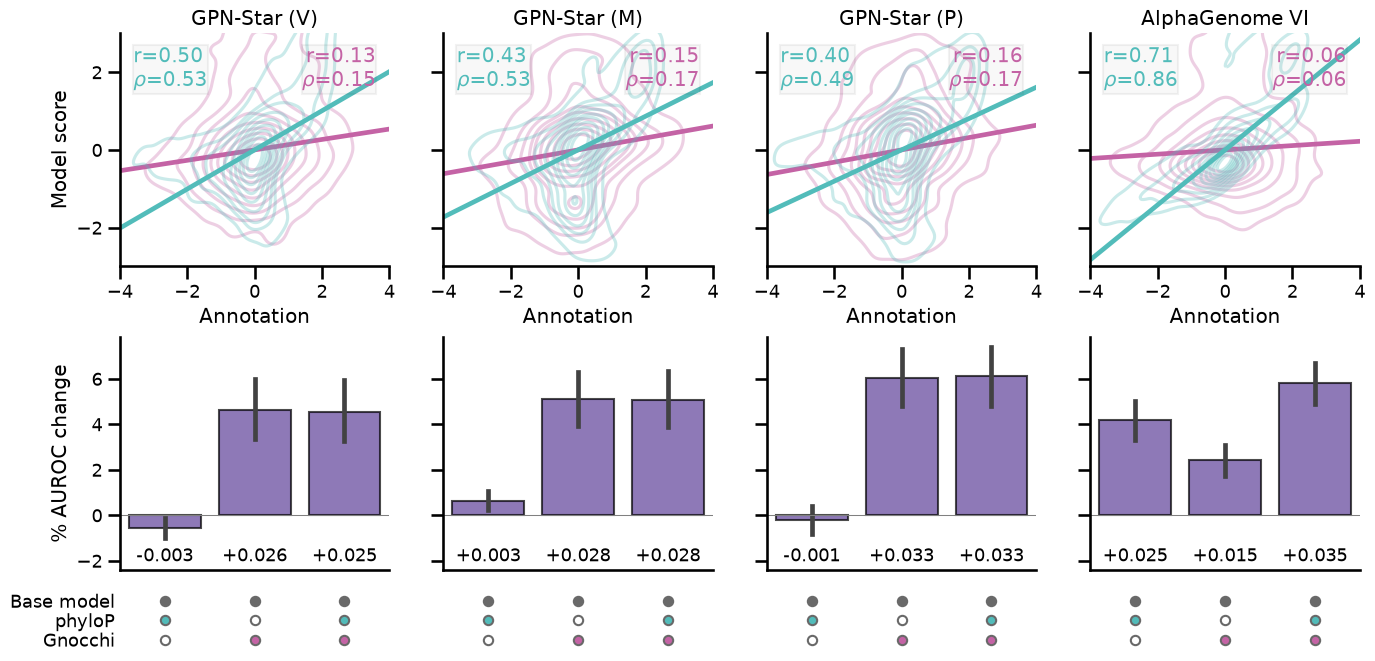

In [137]:
with sns.plotting_context("talk", font_scale=0.8):
    gpn_ag_combined_plot(dataset="All")
    save_fig("fig5_oth_models.pdf")

/tmp/ipykernel_177709/3054537830.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


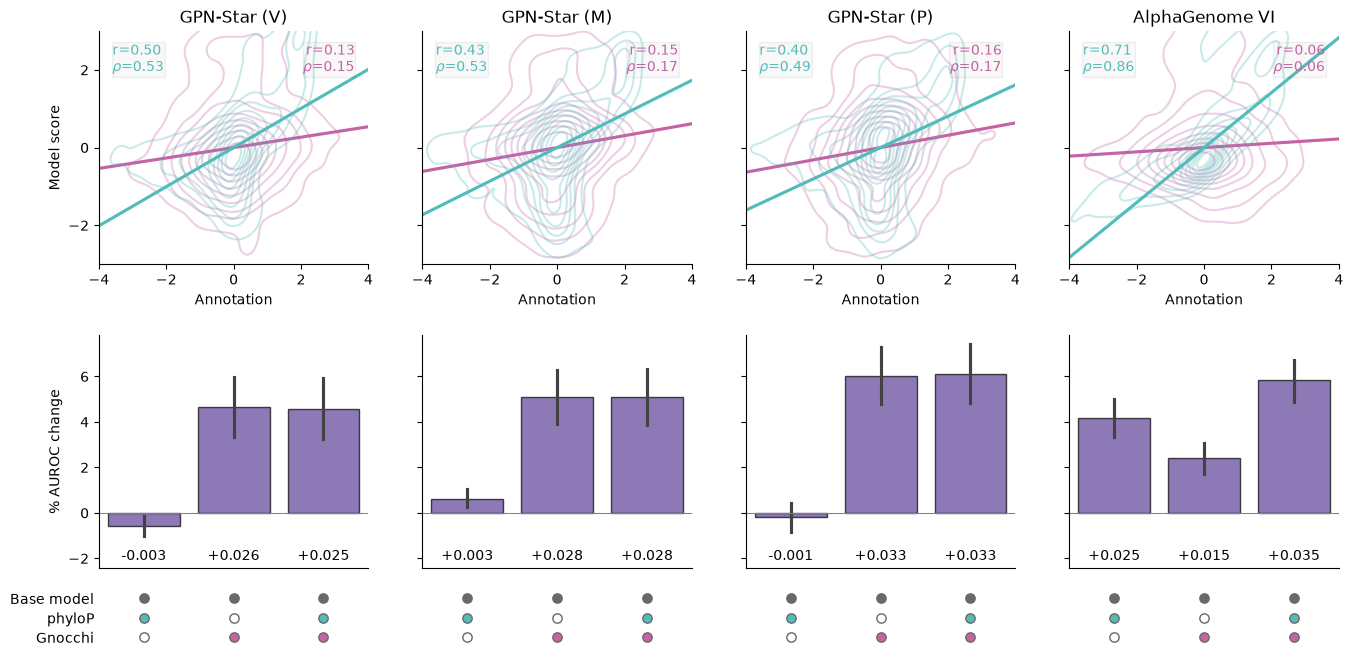

In [86]:
gpn_ag_combined_plot(dataset="All")

## Annotation-major comparison

In [26]:
gw_perf_metrics.get_column("model").unique().sort()

model
str
"""AlphaGenome AVI"""
"""Evo2"""
"""GPN-Star (M)"""
"""GPN-Star (P)"""
"""GPN-Star (V)"""
"""Gnocchi"""
"""NTv3"""
"""NTv3 (100M)"""
"""Orthrus"""


In [27]:
annot_names

{'phylop': 'phyloP', 'gnocchi_z': 'Gnocchi', 'gnomadg_af_log': 'log(MAF)'}

In [ ]:
def make_comparison_lists_for_annotations(
    want_references: list[str],
) -> list[tuple]:
    ret = []
    pretty_to_score = {v: k for k, v in all_models.items()}
    for annotation in ["PhyloP", "Gnocchi"]:
        annot_comparisons = []
        for ref in want_references:
            shorthand = pretty_to_score[ref].replace("_score", "")
            annot_comparisons.append(f"{shorthand}_{annotation.lower()}")
        ret.append((annotation, annot_comparisons))
    return ret


# ms_delta_comparisons = make_comparison_lists(want_references=list(all_models.values()))
gw_annot_comparisons = make_comparison_lists_for_annotations(
    want_references=[
        x for x in all_models.values() if x not in ["ESM-C", "SaProt", "NTv3 (100M)"]
    ],
)
gw_annot_comparisons

[('PhyloP',
  ['evo_phylop',
   'nt_650_phylop',
   'rinalmo_phylop',
   'orthrus_phylop',
   'alphagenome_atlas_raw_phylop',
   'gpn_star_v_phylop',
   'gpn_star_m_phylop',
   'gpn_star_p_phylop']),
 ('Gnocchi',
  ['evo_gnocchi',
   'nt_650_gnocchi',
   'rinalmo_gnocchi',
   'orthrus_gnocchi',
   'alphagenome_atlas_raw_gnocchi',
   'gpn_star_v_gnocchi',
   'gpn_star_m_gnocchi',
   'gpn_star_p_gnocchi'])]

In [ ]:
if ms_regen or not (classification_dir / "gw_annot_bootstraps.pkl").exists():
    gw_annot_bootstrap_metrics, gw_annot_bootstrap_diffs = run_bootstrap_estimates(
        preds=gw_all_preds,
        labels=gw_all_labels,
        groups=gw_all_groups,
        comparisons=gw_annot_comparisons,
    )
    with open(
        classification_dir / "gw_annot_bootstraps.pkl",
        "wb",
    ) as fh:
        dump((gw_annot_bootstrap_metrics, gw_annot_bootstrap_diffs), fh)
else:
    with open(
        classification_dir / "gw_annot_bootstraps.pkl",
        "rb",
    ) as fh:
        gw_annot_bootstrap_metrics, gw_annot_bootstrap_diffs = load(fh)

In [32]:
gw_annot_bootstrap_diffs.head()

auroc,auroc_pct,auprc,auprc_pct,ref,compare,dataset,biotype
f64,f64,f64,f64,str,str,str,str
0.009322,1.359521,0.003714,7.247981,"""PhyloP""","""evo_phylop""","""GWAS""","""all"""
0.001889,0.268218,0.006575,11.503224,"""PhyloP""","""evo_phylop""","""GWAS""","""all"""
0.007814,1.122299,0.007851,13.549371,"""PhyloP""","""evo_phylop""","""GWAS""","""all"""
0.005703,0.809317,0.003404,5.751875,"""PhyloP""","""evo_phylop""","""GWAS""","""all"""
0.003115,0.446617,0.004466,7.622098,"""PhyloP""","""evo_phylop""","""GWAS""","""all"""


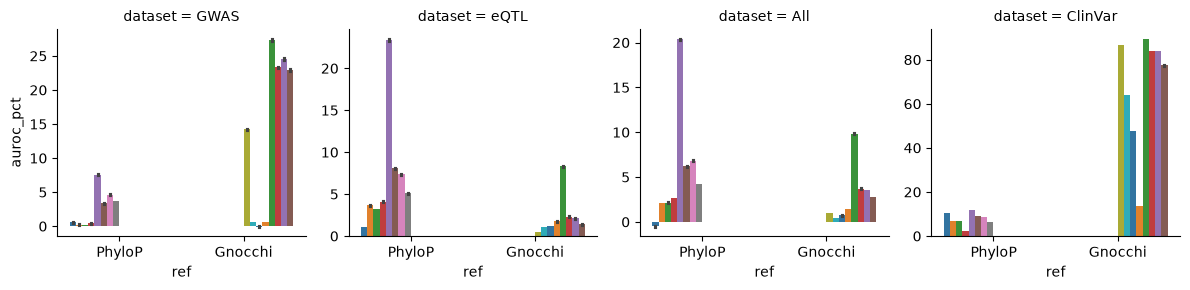

In [ ]:
fg = sns.FacetGrid(
    col="dataset",
    data=gw_annot_bootstrap_diffs,
    sharey=False,
)
fg.map_dataframe(
    sns.barplot,
    x="ref",
    y="auroc_pct",
    hue="compare",
    palette="tab10",
    dodge=True,
)

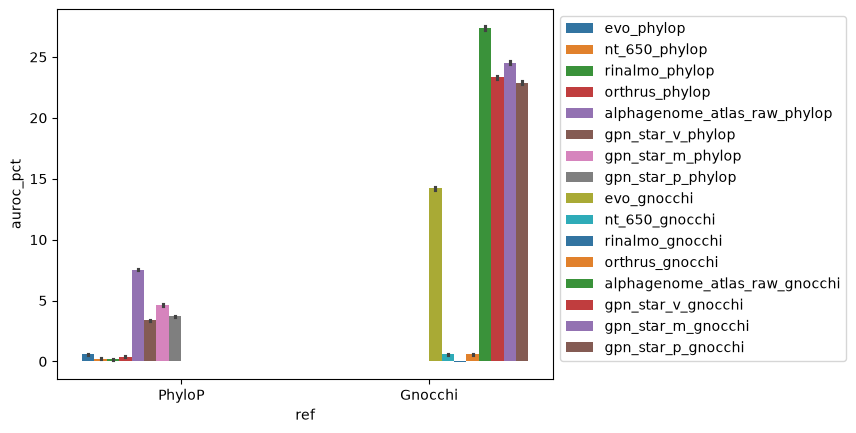

In [ ]:
sns.barplot(
    x="ref",
    y="auroc_pct",
    hue="compare",
    palette="tab10",
    dodge=True,
    data=gw_annot_bootstrap_diffs.filter(dataset="GWAS"),
)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

In [59]:
gw_annot_bootstrap_diffs.filter(ref="Gnocchi", compare="gpn_star_v_gnocchi")

auroc,auroc_pct,auprc,auprc_pct,ref,compare,dataset,biotype
f64,f64,f64,f64,str,str,str,str
0.130449,21.567201,0.041338,188.372943,"""Gnocchi""","""gpn_star_v_gnocchi""","""GWAS""","""all"""
0.126397,21.271008,0.04935,228.187379,"""Gnocchi""","""gpn_star_v_gnocchi""","""GWAS""","""all"""
0.142927,23.670224,0.049575,214.945899,"""Gnocchi""","""gpn_star_v_gnocchi""","""GWAS""","""all"""
0.150033,25.436429,0.049909,242.671184,"""Gnocchi""","""gpn_star_v_gnocchi""","""GWAS""","""all"""
0.141339,24.419381,0.045181,221.127559,"""Gnocchi""","""gpn_star_v_gnocchi""","""GWAS""","""all"""
0.132685,22.066114,0.041576,186.684777,"""Gnocchi""","""gpn_star_v_gnocchi""","""GWAS""","""all"""
0.137339,23.488226,0.04491,222.868895,"""Gnocchi""","""gpn_star_v_gnocchi""","""GWAS""","""all"""
0.145329,24.890209,0.041266,196.271187,"""Gnocchi""","""gpn_star_v_gnocchi""","""GWAS""","""all"""
0.14107,24.124075,0.04316,213.213443,"""Gnocchi""","""gpn_star_v_gnocchi""","""GWAS""","""all"""


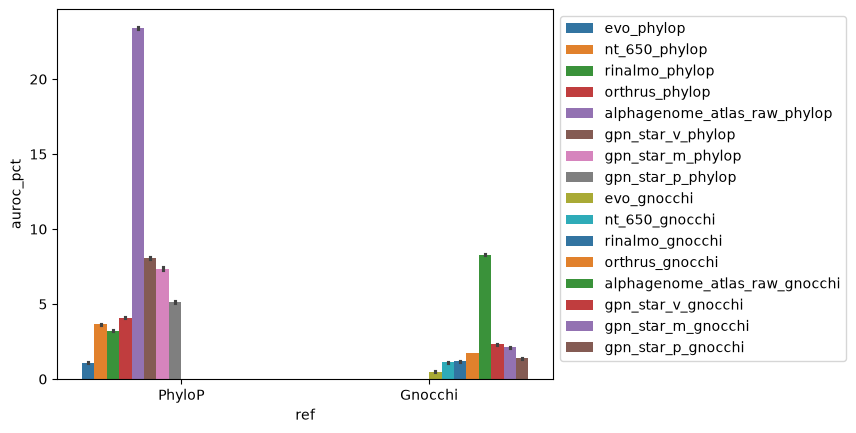

In [ ]:
sns.barplot(
    x="ref",
    y="auroc_pct",
    hue="compare",
    palette="tab10",
    dodge=True,
    data=gw_annot_bootstrap_diffs.filter(dataset="eQTL"),
)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

In [49]:
gw_annot_bootstrap_metrics.head()

auroc,auprc,model,dataset,biotype
f64,f64,str,str,str
0.68567,0.051237,"""PhyloP""","""GWAS""","""all"""
0.704152,0.057158,"""PhyloP""","""GWAS""","""all"""
0.696237,0.057942,"""PhyloP""","""GWAS""","""all"""
0.704653,0.059184,"""PhyloP""","""GWAS""","""all"""
0.697382,0.058588,"""PhyloP""","""GWAS""","""all"""


/tmp/ipykernel_3101466/128045635.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))


(0.45, 0.6555567373844527)

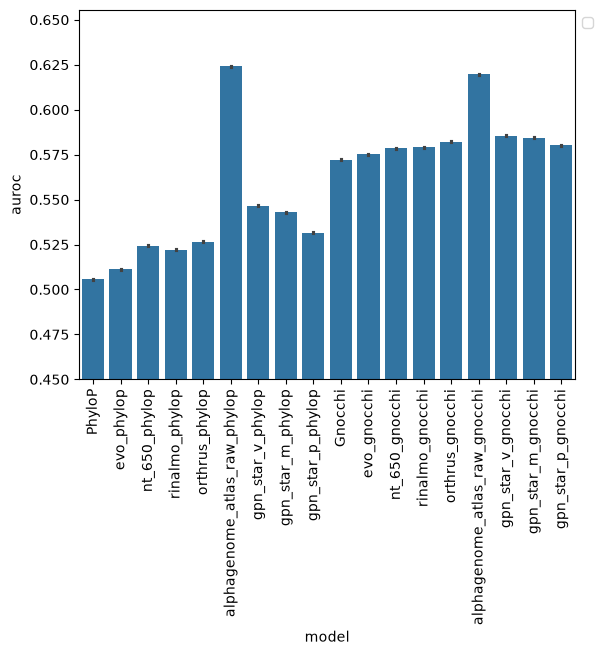

In [56]:
ax = sns.barplot(
    x="model",
    y="auroc",
    dodge=True,
    data=gw_annot_bootstrap_metrics.filter(dataset="eQTL"),
)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation="vertical")
plt.ylim(0.45)